# Training Mask R-CNN v2

This notebook evaluates the second Torchvision Mask R-CNN ResNet50-FPN implementation on the reduced 17-class TACO detection and instance-segmentation task.

## Overview

This notebook implements the main **Mask R-CNN v1 training pipeline** for the project. It applies the findings from the preceding EDA and experiment notebooks, where class ambiguity and the large proportion of small objects were identified as major limitations of detection quality. The objective here is to convert those findings into a reproducible training workflow and evaluate whether the resulting changes improve bounding-box detection and instance segmentation.

The workflow includes:

- construction of instance masks and detection targets from TACO annotations;
- a deterministic train-validation split with weighted sampling for class imbalance;
- geometric and photometric training augmentation;
- a reduced taxonomy that merges overlapping plastic classes and removes ambiguous catch-all annotations;
- staged optimization, beginning with the detection heads and continuing with full-model fine-tuning using separate learning rates;
- cosine learning-rate scheduling, gradient clipping, mixed-precision training, early stopping, and checkpoint recovery;
- a small-object model variant with lower-scale anchors, multi-scale input sizes, and the `map_17` taxonomy.

The primary model-selection metric is **bounding-box mAP@0.5**. Additional bounding-box, mask, recall, overlap, and diagnostic metrics are collected to distinguish localization failures from classification errors. Training history is written to CSV and TensorBoard, while best and latest checkpoints make long runs resumable across sessions.

> Some training cells resume from existing checkpoints. Their paths and starting epochs must match the checkpoint being loaded before the notebook is executed in a new environment.

## Execution Environment

The long-running experiments were executed on a Thunder Compute GPU instance. Paths are selected dynamically so the same notebook can also be opened in Google Colab, but checkpoint and CSV locations must be checked before resuming a run.

Training artifacts are written to persistent storage and synchronized to Google Drive where configured. The notebook should not rely on the lifetime of the local kernel for retaining checkpoints.

## Install Packages

Install the evaluation, augmentation, progress-reporting, and experiment-tracking libraries required by the v2 pipeline. The remote-machine branch also installs `rclone` for copying checkpoints and metrics to Google Drive.

In [1]:
!pip install torchmetrics pycocotools gdown tqdm tensorboard albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.9 MB/s eta 0:00:00


In [2]:
!curl https://rclone.org/install.sh | sudo bash

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4734  100  4734    0     0   8947      0 --:--:-- --:--:-- --:--:--  8948

The latest version of rclone rclone v1.74.3 is already installed.



## Import Packages

Import PyTorch, Torchvision detection components, TorchMetrics, Albumentations, pandas, and plotting utilities. These imports support the complete workflow from target construction through training, evaluation, diagnostics, and CSV visualization.

In [2]:
import os
import pandas as pd
import json
from tqdm import tqdm

import ast
from PIL import Image, ImageDraw
import os
import torch
import math

import numpy as np
from torchvision.io import read_image
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from torch.utils.data import Dataset, Subset, DataLoader, random_split, WeightedRandomSampler
from torch import nn
import random
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torch.utils.tensorboard import SummaryWriter
from matplotlib import colors, pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

from torchvision.ops import box_iou

from torchmetrics.detection import (
    MeanAveragePrecision,
    IntersectionOverUnion,
    GeneralizedIntersectionOverUnion,
    DistanceIntersectionOverUnion,
    CompleteIntersectionOverUnion,
)
from torchmetrics.segmentation import DiceScore, GeneralizedDiceScore, MeanIoU

%matplotlib inline

## Configure Environment Paths

Detect Colab versus a remote Linux runtime, configure dataset and artifact directories, mount Google Drive when necessary, and seed Python, NumPy, and PyTorch for reproducible splitting and sampling.

In [3]:
def is_google_colab() -> bool:
    """Check whether the notebook is running in Google Colab.
    
    Returns:
        bool: ``True`` in a Colab runtime; otherwise ``False``.
    """
    try:
        import google.colab
        return True
    except ImportError:
        return False


IN_COLAB = is_google_colab()

if IN_COLAB:
    ROOT_PATH = "/content"
    DATAFRAME_PATH = "/content/drive/MyDrive/taco_trash"
    DEFAULT_RUNS_PATH = "/content/drive/MyDrive/taco_trash"
else:
    ROOT_PATH = "/home/ubuntu"
    DATAFRAME_PATH = os.path.join(ROOT_PATH, "taco_trash")
    DEFAULT_RUNS_PATH = os.path.join(ROOT_PATH, "taco_trash")

TACO_CLASSIFICATION_PATH = os.path.join(ROOT_PATH, "taco")

In [6]:
if is_google_colab():
    from google.colab import drive
    drive.mount("/content/drive")
else:
    !curl https://rclone.org/install.sh | sudo bash

Mounted at /content/drive


In [7]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [8]:
torch.cuda.current_device()
torch.cuda.get_device_name(0)
device = torch.device("cuda")
device

device(type='cuda')

## Download Data

Download the TACO image archive and processed annotation table when running in an ephemeral environment. The processed table contains the image paths, bounding boxes, polygons, and category metadata used to construct Mask R-CNN targets.

In [9]:
!gdown 1CUxA2TcZFhVJWvNH4qwlOSGDPlxodRPF
!unzip taco.zip -d $ROOT_PATH

Downloading...
From (original): https://drive.google.com/uc?id=1CUxA2TcZFhVJWvNH4qwlOSGDPlxodRPF
From (redirected): https://drive.google.com/uc?id=1CUxA2TcZFhVJWvNH4qwlOSGDPlxodRPF&confirm=t&uuid=054f60d4-d55a-496a-b25f-a88ad554b49f
To: /content/taco.zip
100% 5.23G/5.23G [01:17<00:00, 67.2MB/s]
Archive:  taco.zip
   creating: /content/content/drive/MyDrive/taco_dataset/taco/
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/annotations.json  
   creating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000011.jpg  
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000007.jpg  
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000004.jpg  
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000000.jpg  
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000014.jpg  
  inflating: /content/content/drive/MyDrive/taco_

In [10]:
!gdown 1lj6H8pIbHjgrgNRWHoc41Nr8bi0FZ7mt # annotations_processed.csv

Downloading...
From: https://drive.google.com/uc?id=1lj6H8pIbHjgrgNRWHoc41Nr8bi0FZ7mt
To: /content/annotations_processed.csv
100% 3.10M/3.10M [00:00<00:00, 217MB/s]


In [11]:
def parse_bbox(v):
    if isinstance(v, str):
        return ast.literal_eval(v)
    return v
    
if is_google_colab():
    df = pd.read_csv(os.path.join(ROOT_PATH, "annotations_processed.csv"))
else:
    ann_path = os.path.join(TACO_CLASSIFICATION_PATH, "annotations.json")
    with open(ann_path, "r") as f:
        data = json.load(f)

    print(data.keys())

    for key in data.keys():
        if isinstance(data[key], list):
            print(key, len(data[key]))

    df_images = pd.DataFrame(data["images"])
    df_annotations = pd.DataFrame(data["annotations"])
    df_categories = pd.DataFrame(data["categories"])
    df_scene_annotations = pd.DataFrame(data["scene_annotations"])
    df_scene_categories = pd.DataFrame(data["scene_categories"])

    df = df_annotations.merge(
        df_images,
        left_on="image_id",
        right_on="id",
        how="left",
        suffixes=("", "_img"),
    ).merge(
        df_categories,
        left_on="category_id",
        right_on="id",
        how="left",
        suffixes=("", "_cat"),
    ).rename(
        columns={
            "id_x": "annotation_id",
            "id_y": "category_id_full",
            "name": "category_name",
        }
    )
    df['file_path'] = df['file_name'].map(lambda x: os.path.join(TACO_CLASSIFICATION_PATH, x) )

## Define the Shared Training Pipeline

Define dataset conversion, augmentation, weighted sampling, epoch training, evaluation, checkpointing, scheduling, and metric-flattening helpers. Most functions are shared with the v1 experiments so that the architectural comparison uses the same data split and evaluation logic.

In [12]:
def polygons_to_masks(segmentation, height, width):
    """Rasterize polygon segmentations into binary masks.
    
    Args:
        segmentation (list[list[float]]): Polygon coordinate lists for one instance.
        height (int): Output mask height in pixels.
        width (int): Output mask width in pixels.
    
    Returns:
        torch.Tensor: Stacked masks with shape ``[N, H, W]``.
    """
    masks = []

    for seg in segmentation:
        # Create empty mask
        mask = Image.new("L", (width, height), 0)
        draw = ImageDraw.Draw(mask)

        # Create corrdinates tuples
        polygon = [(seg[i], seg[i+1]) for i in range(0, len(seg), 2)]

        # Fill this mask in empty mask image
        draw.polygon(polygon, outline=1, fill=1)

        #  PIL => numpy => torch
        mask = torch.from_numpy(np.array(mask, dtype=np.uint8))

        masks.append(mask)

    # Combine
    if len(masks) > 0:
        masks = torch.stack(masks)  # [N, H, W]
    else:
        masks = torch.zeros((0, height, width), dtype=torch.uint8)

    return masks

def boxes_from_masks(masks):
    """Compute tight ``xyxy`` bounding boxes from binary masks.
    
    Args:
        masks (torch.Tensor): Binary instance masks with shape ``[N, H, W]``.
    
    Returns:
        torch.Tensor: Bounding boxes with shape ``[N, 4]``.
    """
    boxes = []

    for mask in masks:
        ys, xs = torch.where(mask > 0)

        if len(xs) == 0 or len(ys) == 0:
            boxes.append([0.0, 0.0, 0.0, 0.0])
            continue

        x1 = xs.min().item()
        y1 = ys.min().item()
        x2 = xs.max().item() + 1
        y2 = ys.max().item() + 1

        boxes.append([float(x1), float(y1), float(x2), float(y2)])

    return torch.tensor(boxes, dtype=torch.float32)

def masks_to_boxes(masks):
    """Convert binary instance masks to tight ``xyxy`` boxes.
    
    Args:
        masks (torch.Tensor): Binary instance masks with shape ``[N, H, W]``.
    
    Returns:
        torch.Tensor: Bounding boxes with shape ``[N, 4]``.
    """
    boxes = []

    for mask in masks:
        ys, xs = torch.where(mask > 0)

        if len(xs) == 0 or len(ys) == 0:
            boxes.append([0, 0, 0, 0])
            continue

        x1 = xs.min().item()
        y1 = ys.min().item()
        x2 = xs.max().item() + 1
        y2 = ys.max().item() + 1

        boxes.append([x1, y1, x2, y2])

    return torch.tensor(boxes, dtype=torch.float32)

from PIL import Image, ExifTags

def load_image_with_exif(file_path):
    """Load an RGB image and apply its EXIF orientation.
    
    Args:
        file_path (str): Path to the source image.
    
    Returns:
        torch.Tensor: Normalized image tensor with shape ``[C, H, W]``.
    """
    image = Image.open(file_path).convert("RGB")
    try:
        exif = image._getexif()
        if exif:
            for tag, value in exif.items():
                if ExifTags.TAGS.get(tag) == "Orientation":
                    if value == 3:
                        image = image.rotate(180, expand=True)
                    elif value == 6:
                        image = image.rotate(270, expand=True)
                    elif value == 8:
                        image = image.rotate(90, expand=True)
                    break
    except Exception:
        pass
    return torch.from_numpy(np.array(image)).permute(2, 0, 1).float() / 255.0

class TacoDatasetOriginalBoxes(Dataset):
    def __init__(
        self,
        df,
        label_map,
        label_col="category_id",
        transform=None,
        return_masks=True,
        use_original_boxes=True,
    ):
        """Initialize the image-grouped TACO detection dataset.
        
        Args:
            df (pd.DataFrame): Object-level annotation dataframe.
            label_map (dict): Mapping from dataframe labels to contiguous model class IDs.
            label_col (str): Dataframe column containing the target class label.
            transform (Any | None): Optional joint image-and-mask transformation pipeline.
            return_masks (bool): Whether targets include binary instance masks.
            use_original_boxes (bool): Whether to use annotated boxes instead of mask-derived boxes.
        """
        self.image_groups = list(df.groupby("image_id"))
        self.label_map = label_map
        self.label_col = label_col
        self.transform = transform
        self.return_masks = return_masks
        self.use_original_boxes = use_original_boxes

    def __getitem__(self, idx):
        """Load one image and construct its detection target.
        
        Args:
            idx (int): Image-group index to load.
        
        Returns:
            tuple[torch.Tensor, dict]: Normalized image tensor and its target dictionary.
        """
        image_id, group = self.image_groups[idx]
        file_path = group.iloc[0]["file_path"]

        img = load_image_with_exif(file_path)
        _, H, W = img.shape

        boxes = []
        labels = []
        masks = []

        for _, row in group.iterrows():
            label = self.label_map[row[self.label_col]]
            labels.append(label)

            bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]
            x, y, w, h = bbox
            boxes.append([x, y, x + w, y + h])

            if self.return_masks or self.transform is not None:
                segmentation = ast.literal_eval(row["segmentation"]) if isinstance(row["segmentation"],
                str) else row["segmentation"]
                mask = polygons_to_masks(segmentation, H, W)
                mask = mask.sum(dim=0).clamp(max=1).to(torch.uint8)
                masks.append(mask)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        boxes[:, [0, 2]] = boxes[:, [0, 2]].clamp(0, W)
        boxes[:, [1, 3]] = boxes[:, [1, 3]].clamp(0, H)

        if len(masks) > 0:
            masks = torch.stack(masks)
        else:
            masks = torch.zeros((len(labels), H, W), dtype=torch.uint8)

        if self.transform is not None:
            image_np = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            masks_np = [m.numpy() for m in masks]

            transformed = self.transform(
                image=image_np,
                masks=masks_np,
            )

            image_np = transformed["image"]
            masks_np = transformed["masks"]

            img = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255.0

            masks = torch.stack([
                torch.from_numpy(m.astype(np.uint8))
                for m in masks_np
            ])

            boxes = masks_to_boxes(masks)

        keep = (
            (boxes[:, 2] > boxes[:, 0])
            & (boxes[:, 3] > boxes[:, 1])
        )

        if self.return_masks or self.transform is not None:
            keep = keep & (masks.flatten(1).sum(dim=1) > 0)

        boxes = boxes[keep]
        labels = labels[keep]
        masks = masks[keep]

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id]),
            "area": (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
        }

        if self.return_masks:
            target["masks"] = masks

        return img, target

    def __len__(self):
        """Return the number of unique images in the dataset.
        
        Returns:
            int: Number of image groups.
        """
        return len(self.image_groups)

In [13]:
from collections import Counter

def collate_fn(batch):
    """Transpose detection samples into image and target sequences.
    
    Args:
        batch (list): Detection samples returned by the dataset.
    
    Returns:
        tuple: Tuple containing image and target tuples.
    """
    return tuple(zip(*batch))

def get_loaders(
    df,
    label_map,
    label_col="supercategory_reduced",
    train_transform=None,
    return_masks=True,
    use_original_boxes=True,
    train_batch_size=2,
    val_batch_size=4,
    pin_memory=False,
    num_workers=2
):
    """Build deterministically split loaders with weighted sampling.
    
    Args:
        df (pd.DataFrame): Object-level annotation dataframe.
        label_map (dict): Mapping from dataframe labels to contiguous model class IDs.
        label_col (str): Dataframe column containing the target class label.
        train_transform (Any | None): Optional transformation applied only to training samples.
        return_masks (bool): Whether targets include binary instance masks.
        use_original_boxes (bool): Whether to use annotated boxes instead of mask-derived boxes.
        train_batch_size (int): Number of training images per batch.
        val_batch_size (int): Number of validation images per batch.
        pin_memory (bool): Whether data loaders use pinned host memory.
        num_workers (int): Number of worker processes used by each data loader.
    
    Returns:
        tuple[DataLoader, DataLoader]: Training and validation data loaders.
    """
    base_dataset = TacoDatasetOriginalBoxes(
      df=df,
      label_map=label_map,
      label_col=label_col,
      transform=None,
      return_masks=return_masks,
      use_original_boxes=use_original_boxes
    )

    train_size = int(0.8 * len(base_dataset))
    val_size = len(base_dataset) - train_size

    train_indices, val_indices = torch.utils.data.random_split(
        range(len(base_dataset)),
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    train_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=train_transform,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes
    )

    val_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes
    )
    train_dataset = Subset(train_dataset_full, train_indices.indices)
    val_dataset = Subset(val_dataset_full, val_indices.indices)
    class_counts = Counter()

    for dataset_idx in train_dataset.indices:
        image_id, group = base_dataset.image_groups[dataset_idx]

        labels = [
            label_map[cat_id]
            for cat_id in group[label_col].tolist()
        ]

        class_counts.update(labels)

    class_weights = {
        cls: 1.0 / np.sqrt(count)
        for cls, count in class_counts.items()
    }
    sample_weights = []

    for dataset_idx in train_dataset.indices:
        image_id, group = base_dataset.image_groups[dataset_idx]

        labels = [
            label_map[cat_id]
            for cat_id in group[label_col].tolist()
        ]

        weight = max(class_weights[label] for label in labels)
        sample_weights.append(weight)

    sample_weights = torch.DoubleTensor(sample_weights)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=train_batch_size,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
        sampler=sampler,
        collate_fn=collate_fn
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=val_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
        collate_fn=collate_fn
    )
    return train_loader, val_loader


In [14]:
def get_model(num_classes, train_mode="heads"):
    """Create a Mask R-CNN v1 model with configurable trainable components.
    
    Args:
        num_classes (int): Total class count including the background class.
        train_mode (str): Trainable component set: ``predictors``, ``heads``, or ``all``.
    
    Returns:
        torch.nn.Module: Configured model moved to the active device.
    """
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(
        weights="DEFAULT",
        min_size=1024,
        max_size=1536,
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        256,
        num_classes,
    )

    for p in model.parameters():
        p.requires_grad = False

    if train_mode == "predictors":
        for p in model.roi_heads.box_predictor.parameters():
            p.requires_grad = True
        for p in model.roi_heads.mask_predictor.parameters():
            p.requires_grad = True

    elif train_mode == "heads":
        for p in model.rpn.parameters():
            p.requires_grad = True
        for p in model.roi_heads.parameters():
            p.requires_grad = True

    elif train_mode == "all":
        for p in model.parameters():
            p.requires_grad = True

    model.to(device)
    return model

def set_train_mode(model, train_mode):
    """Freeze the model and enable parameters selected by a training mode.
    
    Args:
        model (torch.nn.Module): Torchvision detection model.
        train_mode (str): Trainable component set: ``predictors``, ``heads``, or ``all``.
    
    Raises:
        ValueError: If ``train_mode`` is unsupported.
    """
    for p in model.parameters():
        p.requires_grad = False

    if train_mode == "predictors":
        for p in model.roi_heads.box_predictor.parameters():
            p.requires_grad = True
        for p in model.roi_heads.mask_predictor.parameters():
            p.requires_grad = True

    elif train_mode == "heads":
        for p in model.rpn.parameters():
            p.requires_grad = True
        for p in model.roi_heads.parameters():
            p.requires_grad = True

    elif train_mode == "all":
        for p in model.parameters():
            p.requires_grad = True

    else:
        raise ValueError(f"Unknown train_mode: {train_mode}")

def get_model_v2(num_classes, train_mode="heads"):
      """Create a Mask R-CNN v2 model with configurable trainable components.
      
      Args:
          num_classes (int): Total class count including the background class.
          train_mode (str): Trainable component set: ``predictors``, ``heads``, or ``all``.
      
      Returns:
          torch.nn.Module: Configured model moved to the active device.
      
      Raises:
          ValueError: If ``train_mode`` is unsupported.
      """
      model = torchvision.models.detection.maskrcnn_resnet50_fpn_v2(
          weights="DEFAULT",
          min_size=1024,
          max_size=1536,
      )

      in_features = model.roi_heads.box_predictor.cls_score.in_features
      model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

      in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
      model.roi_heads.mask_predictor = MaskRCNNPredictor(
          in_features_mask,
          256,
          num_classes,
      )

      for p in model.parameters():
          p.requires_grad = False

      if train_mode == "predictors":
          for p in model.roi_heads.box_predictor.parameters():
              p.requires_grad = True
          for p in model.roi_heads.mask_predictor.parameters():
              p.requires_grad = True

      elif train_mode == "heads":
          for p in model.rpn.parameters():
              p.requires_grad = True
          for p in model.roi_heads.parameters():
              p.requires_grad = True

      elif train_mode == "all":
          for p in model.parameters():
              p.requires_grad = True

      else:
          raise ValueError(f"Unknown train_mode: {train_mode}")

      model.to(device)
      return model

In [15]:
def fit_one_epoch(model, train_dataloader, optimizer, device, epoch, scaler=None, max_grad_norm=5.0):
    """Optimize the model for one epoch and aggregate training losses.
    
    Args:
        model (torch.nn.Module): Torchvision detection model.
        train_dataloader (DataLoader): Data loader providing training images and targets.
        optimizer (torch.optim.Optimizer): Optimizer for trainable model parameters.
        device (torch.device | str): Device used for model computation.
        epoch (int): Zero-based epoch index.
        scaler (torch.amp.GradScaler | None): Optional mixed-precision gradient scaler.
        max_grad_norm (float): Maximum gradient norm used for clipping.
    
    Returns:
        dict[str, float]: Mean losses, gradient norm, and epoch index.
    
    Raises:
        ValueError: If no batch is processed successfully.
    """
    model.to(device)
    model.train()

    total_loss_sum = 0.0
    num_batches = 0

    loss_sums = {
        "loss_classifier": 0.0,
        "loss_box_reg": 0.0,
        "loss_mask": 0.0,
        "loss_objectness": 0.0,
        "loss_rpn_box_reg": 0.0,
    }

    loader = tqdm(
        train_dataloader,
        total=len(train_dataloader),
        position=0,
        leave=True,
        dynamic_ncols=True,
        desc=f"Epoch {epoch+1}. Train"
    )
    for batch_idx, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=scaler is not None):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())


        if not torch.isfinite(losses):
          print(f"non-finite loss at batch {batch_idx}")
          break

        if losses.item() > 1e6:
            print(f"exploding loss at batch {batch_idx}")
            print("targets summary:")
            for i, t in enumerate(targets):
                print(
                    i,
                    t["boxes"].shape,
                    t["labels"].tolist(),
                    t["masks"].shape,
                )
            break

        if scaler is not None:
            scaler.scale(losses).backward()
            scaler.unscale_(optimizer)

            grad_norm = torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=max_grad_norm,
            )

            scaler.step(optimizer)
            scaler.update()
        else:
            losses.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                max_norm=max_grad_norm,
            )

            optimizer.step()

        total_loss_sum += losses.item()
        num_batches += 1

        for key in loss_sums:
            loss_sums[key] += loss_dict[key].item()

    if num_batches == 0:
        raise ValueError(
            f"fit_one_epoch: no successful batches were processed in epoch {epoch}"
        )

    metrics = {
        "epoch": epoch,
        "total_loss": total_loss_sum / num_batches,
        "grad_norm": float(grad_norm.detach().cpu()) if isinstance(grad_norm, torch.Tensor) else
          float(grad_norm),
    }

    for key in loss_sums:
        metrics[key] = loss_sums[key] / num_batches

    return metrics

In [16]:
def _to_float(x):
    """Convert a finite scalar tensor or number to a Python float.
    
    Args:
        x (Any): Value to convert.
    
    Returns:
        float | None: Finite scalar value, or ``None`` when unsupported.
    """
    if isinstance(x, torch.Tensor):
        if x.numel() == 1:
            value = float(x.detach().cpu().item())
            if math.isnan(value) or math.isinf(value):
                return None
            return value
        return None

    if isinstance(x, (int, float)):
        value = float(x)
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    return None

def _to_list(x):
    """Convert tensor or scalar metric values to a Python list.
    
    Args:
        x (Any): Value to convert.
    
    Returns:
        list: Converted values, or an empty list when unsupported.
    """
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu()
        if x.ndim == 0:
            return [x.item()]
        return x.tolist()

    if isinstance(x, (int, float)):
        return [float(x)]

    if isinstance(x, list):
        return x

    return []

def iou_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    # Lets compute metrics for some threshold
    # first convert mask values to probabilities, then
    # apply thresholding

    """Calculate binary mask intersection over union.
    
    Args:
        logits (torch.Tensor): Raw mask prediction logits.
        labels (torch.Tensor): Binary ground-truth mask values.
        threshold (float): Probability threshold used to binarize predictions.
    
    Returns:
        torch.Tensor: Scalar IoU value.
    """
    prob_mask = logits.sigmoid()
    pred_mask = (prob_mask > threshold).float()

    tp = torch.sum(pred_mask*labels)
    fp = torch.sum(pred_mask) - tp
    fn = torch.sum(labels) - tp

    eps = 1e-8 # to avoid 0/0
    iou = (tp + eps) / (tp + fp + fn + eps)

    return iou

def prepare_detection_batch(preds, targets, mask_threshold=0.5):
    """Convert detector outputs and targets into TorchMetrics inputs.
    
    Args:
        preds (list[dict[str, torch.Tensor]]): Per-image model predictions.
        targets (list[dict[str, torch.Tensor]]): Per-image ground-truth targets.
        mask_threshold (float): Probability threshold used to binarize predicted masks.
    
    Returns:
        tuple[list, list, list, list]: Bounding-box and segmentation predictions and targets.
    """
    bbox_preds = []
    bbox_targets = []

    segm_preds = []
    segm_targets = []

    for pred, target in zip(preds, targets):
        pred_boxes = pred["boxes"].detach().cpu()
        pred_scores = pred["scores"].detach().cpu()
        pred_labels = pred["labels"].detach().cpu().to(torch.int64)

        gt_boxes = target["boxes"].detach().cpu()
        gt_labels = target["labels"].detach().cpu().to(torch.int64)

        bbox_preds.append({
            "boxes": pred_boxes,
            "scores": pred_scores,
            "labels": pred_labels,
        })

        bbox_targets.append({
            "boxes": gt_boxes,
            "labels": gt_labels,
        })

        segm_pred = {
            "boxes": pred_boxes,
            "scores": pred_scores,
            "labels": pred_labels,
        }
        if "masks" in pred:
            # pred masks come as [N, 1, H, W] floats
            segm_pred["masks"] = (pred["masks"].detach().cpu().squeeze(1) >= mask_threshold)

        segm_target = {
            "boxes": gt_boxes,
            "labels": gt_labels,
        }
        if "masks" in target:
            # gt masks are [N, H, W]
            segm_target["masks"] = target["masks"].detach().cpu().bool()

        segm_preds.append(segm_pred)
        segm_targets.append(segm_target)

    return bbox_preds, bbox_targets, segm_preds, segm_targets

def match_instance_masks(pred, target, box_iou_threshold=0.5, mask_threshold=0.5):
    """Match same-class instances by box IoU and return their masks.
    
    Args:
        pred (dict[str, torch.Tensor]): Predictions for one image.
        target (dict[str, torch.Tensor]): Ground-truth target for one image.
        box_iou_threshold (float): Minimum box IoU required for an instance match.
        mask_threshold (float): Probability threshold used to binarize predicted masks.
    
    Returns:
        tuple[torch.Tensor | None, torch.Tensor | None]: Matched predicted and ground-truth masks, or ``None`` values.
    """
    if len(pred["boxes"]) == 0 or len(target["boxes"]) == 0:
        return None, None

    pred_boxes = pred["boxes"].detach().cpu()
    pred_labels = pred["labels"].detach().cpu()
    pred_masks = (pred["masks"].detach().cpu().squeeze(1) >= mask_threshold)  # [Np, H, W]

    gt_boxes = target["boxes"].detach().cpu()
    gt_labels = target["labels"].detach().cpu()
    gt_masks = target["masks"].detach().cpu().bool()  # [Ng, H, W]

    ious = box_iou(pred_boxes, gt_boxes)  # [Np, Ng]
    same_label = pred_labels[:, None] == gt_labels[None, :]
    ious = ious * same_label.float()

    matched_pred_masks = []
    matched_gt_masks = []

    used_pred = set()
    used_gt = set()

    while True:
        max_iou = ious.max().item()
        if max_iou < box_iou_threshold:
            break

        flat_idx = ious.argmax().item()
        num_gt = ious.shape[1]
        pred_idx = flat_idx // num_gt
        gt_idx = flat_idx % num_gt

        if pred_idx in used_pred or gt_idx in used_gt:
            ious[pred_idx, gt_idx] = -1
            continue

        matched_pred_masks.append(pred_masks[pred_idx].long())
        matched_gt_masks.append(gt_masks[gt_idx].long())

        used_pred.add(pred_idx)
        used_gt.add(gt_idx)

        ious[pred_idx, :] = -1
        ious[:, gt_idx] = -1

    if len(matched_pred_masks) == 0:
        return None, None

    return torch.stack(matched_pred_masks), torch.stack(matched_gt_masks)

In [17]:
def prepare_eval_metrics_for_tensorboard(eval_results, id_to_name=None):
    """Flatten nested evaluation metrics into TensorBoard scalars.
    
    Args:
        eval_results (dict): Nested metrics returned by an evaluation epoch.
        id_to_name (dict[int, str] | None): Optional mapping from model IDs to readable class names.
    
    Returns:
        dict[str, float]: Finite scalar metrics keyed by log name.
    """
    flat = {}

    # bbox mAP dict
    bbox_map = eval_results["bbox_map"]
    flat["eval/bbox_map"] = _to_float(bbox_map.get("map"))
    flat["eval/bbox_map_50"] = _to_float(bbox_map.get("map_50"))
    flat["eval/bbox_map_75"] = _to_float(bbox_map.get("map_75"))
    flat["eval/bbox_mar_100"] = _to_float(bbox_map.get("mar_100"))

    # segm mAP dict
    if "segm_map" in eval_results:
        segm_map = eval_results["segm_map"]
        flat["eval/segm_map"] = _to_float(segm_map.get("map"))
        flat["eval/segm_map_50"] = _to_float(segm_map.get("map_50"))
        flat["eval/segm_map_75"] = _to_float(segm_map.get("map_75"))
        flat["eval/segm_mar_100"] = _to_float(segm_map.get("mar_100"))

    # box overlap metrics
    if "bbox_iou" in eval_results:
        flat["eval/bbox_iou"] = _to_float(eval_results["bbox_iou"])
        flat["eval/bbox_giou"] = _to_float(eval_results["bbox_giou"])
        flat["eval/bbox_diou"] = _to_float(eval_results["bbox_diou"])
        flat["eval/bbox_ciou"] = _to_float(eval_results["bbox_ciou"])

    # mask metrics
    if "dice" in eval_results:
        flat["eval/dice"] = _to_float(eval_results["dice"])
        flat["eval/generalized_dice"] = _to_float(eval_results["generalized_dice"])
        flat["eval/mask_miou"] = _to_float(eval_results["mask_miou"])

    if "debug" in eval_results:
        for key, value in eval_results["debug"].items():
            flat[f"eval/{key}"] = _to_float(value)

    # Per-class bbox AP
    if "classes" in bbox_map and "map_per_class" in bbox_map:
        classes = _to_list(bbox_map["classes"])
        values = _to_list(bbox_map["map_per_class"])

        for cls, value in zip(classes, values):
            cls = int(cls)
            cls_name = id_to_name.get(cls, str(cls)) if id_to_name else str(cls)
            flat[f"eval_per_class/bbox_map/{cls_name}"] = _to_float(value)

    # Per-class bbox recall
    if "classes" in bbox_map and "mar_100_per_class" in bbox_map:
        classes = _to_list(bbox_map["classes"])
        values = _to_list(bbox_map["mar_100_per_class"])

        for cls, value in zip(classes, values):
            cls = int(cls)
            cls_name = id_to_name.get(cls, str(cls)) if id_to_name else str(cls)
            flat[f"eval_per_class/bbox_mar_100/{cls_name}"] = _to_float(value)

    # Per-class mask AP
    if "segm_map" in eval_results:
        segm_map = eval_results["segm_map"]
        if "classes" in segm_map and "map_per_class" in segm_map:
            classes = _to_list(segm_map["classes"])
            values = _to_list(segm_map["map_per_class"])

            for cls, value in zip(classes, values):
                cls = int(cls)
                cls_name = id_to_name.get(cls, str(cls)) if id_to_name else str(cls)
                flat[f"eval_per_class/segm_map/{cls_name}"] = _to_float(value)

    # remove unsupported / None values
    flat = {k: v for k, v in flat.items() if v is not None}
    return flat

def prepare_train_metrics_for_tensorboard(train_metrics):
    """Convert training losses into TensorBoard scalar names.
    
    Args:
        train_metrics (dict): Metrics collected during the current training epoch.
    
    Returns:
        dict[str, float]: Training metrics keyed by log name.
    """
    return {
        "train/total_loss": float(train_metrics["total_loss"]),
        "train/loss_classifier": float(train_metrics["loss_classifier"]),
        "train/loss_box_reg": float(train_metrics["loss_box_reg"]),
        "train/loss_mask": float(train_metrics["loss_mask"]),
        "train/loss_objectness": float(train_metrics["loss_objectness"]),
        "train/loss_rpn_box_reg": float(train_metrics["loss_rpn_box_reg"]),
    }

In [18]:
from torchvision.ops import box_iou

def detection_debug_stats(outputs, targets, score_threshold=0.05, iou_threshold=0.5):
    """Collect confidence, localization, and class-match diagnostics.
    
    Args:
        outputs (list[dict[str, torch.Tensor]]): Per-image detector outputs.
        targets (list[dict[str, torch.Tensor]]): Per-image ground-truth targets.
        score_threshold (float): Minimum confidence required to retain a prediction.
        iou_threshold (float): Minimum IoU required for geometric matching.
    
    Returns:
        dict: Aggregated detection diagnostic counters and score lists.
    """
    stats = {
        "gt_instances": 0,
        "pred_instances": 0,
        "matched_instances": 0,
        "class_correct_matches": 0,
        "images_with_no_predictions": 0,
        "images_with_no_matches": 0,
        "top1_scores": [],
        "matched_scores": [],
        "unmatched_scores": [],
    }

    for out, target in zip(outputs, targets):
        scores = out["scores"].detach().cpu()
        keep = scores >= score_threshold

        pred_boxes = out["boxes"].detach().cpu()[keep]
        pred_labels = out["labels"].detach().cpu()[keep]
        pred_scores = scores[keep]

        gt_boxes = target["boxes"].detach().cpu()
        gt_labels = target["labels"].detach().cpu()

        stats["gt_instances"] += len(gt_boxes)
        stats["pred_instances"] += len(pred_boxes)

        if len(scores) > 0:
            stats["top1_scores"].append(float(scores[0]))

        if len(pred_boxes) == 0:
            stats["images_with_no_predictions"] += 1
            stats["images_with_no_matches"] += 1
            continue

        if len(gt_boxes) == 0:
            stats["unmatched_scores"].extend(pred_scores.tolist())
            continue

        ious = box_iou(pred_boxes, gt_boxes)

        matched_pred = set()
        matched_gt = set()

        while ious.numel() > 0:
            max_iou = ious.max().item()
            if max_iou < iou_threshold:
                break

            flat_idx = ious.argmax().item()
            pred_idx = flat_idx // ious.shape[1]
            gt_idx = flat_idx % ious.shape[1]

            if pred_idx in matched_pred or gt_idx in matched_gt:
                ious[pred_idx, gt_idx] = -1
                continue

            matched_pred.add(pred_idx)
            matched_gt.add(gt_idx)

            stats["matched_instances"] += 1
            stats["matched_scores"].append(float(pred_scores[pred_idx]))

            if int(pred_labels[pred_idx]) == int(gt_labels[gt_idx]):
                stats["class_correct_matches"] += 1

            ious[pred_idx, :] = -1
            ious[:, gt_idx] = -1

        if len(matched_gt) == 0:
            stats["images_with_no_matches"] += 1

        for pred_idx, score in enumerate(pred_scores):
            if pred_idx not in matched_pred:
                stats["unmatched_scores"].append(float(score))

    return stats

In [19]:
@torch.no_grad()
def eval_one_epoch(
    model,
    val_dataloader,
    device,
    epoch,
    score_threshold=0.3,
    mask_threshold=0.3,
    detections_per_img=5,
    match_iou_threshold=0.5,
    fast=False
):
    """Evaluate bounding-box metrics and optionally full mask metrics.
    
    Args:
        model (torch.nn.Module): Torchvision detection model.
        val_dataloader (DataLoader): Data loader providing validation images and targets.
        device (torch.device | str): Device used for model computation.
        epoch (int): Zero-based epoch index.
        score_threshold (float): Minimum confidence required to retain a prediction.
        mask_threshold (float): Probability threshold used to binarize predicted masks.
        detections_per_img (int): Maximum number of predictions retained per image.
        match_iou_threshold (float): Minimum box IoU used for diagnostic instance matching.
        fast (bool): Whether to skip expensive mask and overlap metrics.
    
    Returns:
        dict: Evaluation metrics and detection diagnostics.
    """
    model.eval()
    running_debug = {
        "gt_instances": 0,
        "pred_instances": 0,
        "matched_instances": 0,
        "class_correct_matches": 0,
        "images_with_no_predictions": 0,
        "images_with_no_matches": 0,
        "top1_scores": [],
        "matched_scores": [],
        "unmatched_scores": [],
    }
    model.roi_heads.score_thresh = score_threshold
    model.roi_heads.detections_per_img = detections_per_img

    bbox_map = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    if not fast:
        segm_map = MeanAveragePrecision(box_format="xyxy", iou_type="segm")

        bbox_iou_metric = IntersectionOverUnion()
        bbox_giou_metric = GeneralizedIntersectionOverUnion()
        bbox_diou_metric = DistanceIntersectionOverUnion()
        bbox_ciou_metric = CompleteIntersectionOverUnion()

        dice_metric = DiceScore(
            num_classes=2,
            average="micro",
            include_background=False,
            input_format="index",
        )
        gdice_metric = GeneralizedDiceScore(
            num_classes=2,
            include_background=False,
            input_format="index",
        )
        miou_metric = MeanIoU(
            num_classes=2,
            include_background=False,
            input_format="index",
        )

    matched_mask_count = 0

    loader = tqdm(
        val_dataloader,
        total=len(val_dataloader),
        position=0,
        leave=True,
        dynamic_ncols=True,
        desc=f"Epoch {epoch+1}. Eval"
)
    for batch_idx, (images, targets) in enumerate(loader):

        images = [img.to(device) for img in images]

        with torch.amp.autocast("cuda"):
            outputs = model(images)

        debug_stats = detection_debug_stats(
            outputs=outputs,
            targets=targets,
            score_threshold=0.05,
            iou_threshold=0.5,
        )

        for key in [
            "gt_instances",
            "pred_instances",
            "matched_instances",
            "class_correct_matches",
            "images_with_no_predictions",
            "images_with_no_matches",
        ]:
            running_debug[key] += debug_stats[key]

        for key in [
            "top1_scores",
            "matched_scores",
            "unmatched_scores",
        ]:
            running_debug[key].extend(debug_stats[key])

        bbox_preds, bbox_targets, segm_preds, segm_targets = prepare_detection_batch(
            outputs,
            targets,
            mask_threshold=mask_threshold,
        )

        bbox_map.update(bbox_preds, bbox_targets)
        # segm_map.update(segm_preds, segm_targets)
        if not fast:
            if any("masks" in p for p in segm_preds):
                segm_map.update(segm_preds, segm_targets)

            bbox_iou_metric.update(bbox_preds, bbox_targets)
            bbox_giou_metric.update(bbox_preds, bbox_targets)
            bbox_diou_metric.update(bbox_preds, bbox_targets)
            bbox_ciou_metric.update(bbox_preds, bbox_targets)

            for target, out in zip(targets, outputs):
                if "masks" not in out or "masks" not in target:
                    continue

                pred_masks, gt_masks = match_instance_masks(
                    out,
                    target,
                    box_iou_threshold=match_iou_threshold,
                    mask_threshold=mask_threshold,
                )

                if pred_masks is None:
                    continue

                dice_metric.update(pred_masks, gt_masks)
                gdice_metric.update(pred_masks, gt_masks)
                miou_metric.update(pred_masks, gt_masks)

                matched_mask_count += pred_masks.shape[0]

        del images, outputs

    if matched_mask_count > 0:
        dice = dice_metric.compute()
        generalized_dice = gdice_metric.compute()
        mask_miou = miou_metric.compute()
    else:
        dice = torch.tensor(float("nan"))
        generalized_dice = torch.tensor(float("nan"))
        mask_miou = torch.tensor(float("nan"))

    gt = max(running_debug["gt_instances"], 1)
    matched = max(running_debug["matched_instances"], 1)

    debug_results = {
        "gt_instances": running_debug["gt_instances"],
        "pred_instances": running_debug["pred_instances"],
        "matched_instances": running_debug["matched_instances"],
        "match_rate": running_debug["matched_instances"] / gt,
        "class_accuracy_on_matches": running_debug["class_correct_matches"] / matched,
        "images_with_no_predictions": running_debug["images_with_no_predictions"],
        "images_with_no_matches": running_debug["images_with_no_matches"],
        "mean_top1_score": float(np.mean(running_debug["top1_scores"])) if running_debug["top1_scores"] else
        0.0,
        "mean_matched_score": float(np.mean(running_debug["matched_scores"])) if
        running_debug["matched_scores"] else 0.0,
        "mean_unmatched_score": float(np.mean(running_debug["unmatched_scores"])) if
        running_debug["unmatched_scores"] else 0.0,
    }

    results = {
        "epoch": epoch,
        "bbox_map": bbox_map.compute(),
        "debug": debug_results,
    }

    if not fast:
        results.update({
            "segm_map":        segm_map.compute(),
            "bbox_iou":        bbox_iou_metric.compute(),
            "bbox_giou":       bbox_giou_metric.compute(),
            "bbox_diou":       bbox_diou_metric.compute(),
            "bbox_ciou":       bbox_ciou_metric.compute(),
            "dice":            dice if matched_mask_count > 0 else torch.tensor(float("nan")),
            "generalized_dice": generalized_dice if matched_mask_count > 0 else torch.tensor(float("nan")),
            "mask_miou":       mask_miou if matched_mask_count > 0 else torch.tensor(float("nan")),
        })

    torch.cuda.empty_cache()
    return results

@torch.no_grad()
def eval_one_epoch_bbox_only(
    model,
    val_dataloader,
    device,
    epoch,
    score_threshold=0.05,
    detections_per_img=20,
    match_iou_threshold=0.5,
):
    """Evaluate bounding-box mAP and diagnostics without mask metrics.
    
    Args:
        model (torch.nn.Module): Torchvision detection model.
        val_dataloader (DataLoader): Data loader providing validation images and targets.
        device (torch.device | str): Device used for model computation.
        epoch (int): Zero-based epoch index.
        score_threshold (float): Minimum confidence required to retain a prediction.
        detections_per_img (int): Maximum number of predictions retained per image.
        match_iou_threshold (float): Minimum box IoU used for diagnostic instance matching.
    
    Returns:
        dict: Bounding-box metrics and detection diagnostics.
    """
    model.eval()
    model.transform.min_size = (1024,)

    previous_score_thresh = model.roi_heads.score_thresh
    previous_detections_per_img = model.roi_heads.detections_per_img

    model.roi_heads.score_thresh = score_threshold
    model.roi_heads.detections_per_img = detections_per_img

    bbox_map = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")

    running_debug = {
        "gt_instancess": 0,
        "pred_instances": 0,
        "matched_instances": 0,
        "class_correct_matches": 0,
        "images_with_no_predictions": 0,
        "images_with_no_matches": 0,
        "top1_scores": [],
        "matched_scores": [],
        "unmatched_scores": [],
    }

    loader = tqdm(
        val_dataloader,
        total=len(val_dataloader),
        position=0,
        leave=True,
        dynamic_ncols=True,
        desc=f"Epoch {epoch + 1}. BBox Eval",
    )

    try:
        for batch_idx, (images, targets) in enumerate(loader):
            images = [img.to(device) for img in images]

            with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
                outputs = model(images)

            targets_for_metrics = [
                {
                    "boxes": t["boxes"].detach().cpu(),
                    "labels": t["labels"].detach().cpu().to(torch.int64),
                }
                for t in targets
            ]

            preds_for_metrics = [
                {
                    "boxes": out["boxes"].detach().cpu(),
                    "scores": out["scores"].detach().cpu(),
                    "labels": out["labels"].detach().cpu().to(torch.int64),
                }
                for out in outputs
            ]

            debug_stats = detection_debug_stats(
                outputs=preds_for_metrics,
                targets=targets_for_metrics,
                score_threshold=score_threshold,
                iou_threshold=match_iou_threshold,
            )

            for key in [
                "gt_instances",
                "pred_instances",
                "matched_instances",
                "class_correct_matches",
                "images_with_no_predictions",
                "images_with_no_matches",
            ]:
                running_debug[key] += debug_stats[key]

            for key in [
                "top1_scores",
                "matched_scores",
                "unmatched_scores",
            ]:
                running_debug[key].extend(debug_stats[key])

            bbox_map.update(preds_for_metrics, targets_for_metrics)

            del images, outputs, preds_for_metrics

    finally:
        model.roi_heads.score_thresh = previous_score_thresh
        model.roi_heads.detections_per_img = previous_detections_per_img

    gt = max(running_debug["gt_instances"], 1)
    matched = max(running_debug["matched_instances"], 1)

    debug_results = {
        "gt_instances": running_debug["gt_instances"],
        "pred_instances": running_debug["pred_instances"],
        "matched_instances": running_debug["matched_instances"],
        "match_rate": running_debug["matched_instances"] / gt,
        "class_accuracy_on_matches": running_debug["class_correct_matches"] / matched,
        "images_with_no_predictions": running_debug["images_with_no_predictions"],
        "images_with_no_matches": running_debug["images_with_no_matches"],
        "mean_top1_score": (
            float(np.mean(running_debug["top1_scores"]))
            if running_debug["top1_scores"]
            else 0.0
        ),
        "mean_matched_score": (
            float(np.mean(running_debug["matched_scores"]))
            if running_debug["matched_scores"]
            else 0.0
        ),
        "mean_unmatched_score": (
            float(np.mean(running_debug["unmatched_scores"]))
            if running_debug["unmatched_scores"]
            else 0.0
        ),
    }

    return {
        "epoch": epoch,
        "bbox_map": bbox_map.compute(),
        "debug": debug_results,
    }

In [20]:
def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch, score, metrics):
    """Serialize model and training state to disk.
    
    Args:
        path (str): Checkpoint file path.
        model (torch.nn.Module): Torchvision detection model.
        optimizer (torch.optim.Optimizer): Optimizer for trainable model parameters.
        scheduler (Any | None): Optional learning-rate scheduler.
        scaler (torch.amp.GradScaler | None): Optional mixed-precision gradient scaler.
        epoch (int): Zero-based epoch index.
        score (float): Model-selection score stored in the checkpoint.
        metrics (dict): Training and validation metrics stored with the checkpoint.
    """
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "score": score,
        "metrics": metrics,
    }

    if scheduler is not None:
        checkpoint["scheduler_state_dict"] = scheduler.state_dict()

    if scaler is not None:
        checkpoint["scaler_state_dict"] = scaler.state_dict()

    torch.save(checkpoint, path)

def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None, device="cuda"):
    """Restore model and optional training state from disk.
    
    Args:
        path (str): Checkpoint file path.
        model (torch.nn.Module): Torchvision detection model.
        optimizer (torch.optim.Optimizer): Optimizer for trainable model parameters.
        scheduler (Any | None): Optional learning-rate scheduler.
        scaler (torch.amp.GradScaler | None): Optional mixed-precision gradient scaler.
        device (torch.device | str): Device used for model computation.
    
    Returns:
        dict: Loaded checkpoint dictionary.
    """
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)

    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler is not None and "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    if scaler is not None and "scaler_state_dict" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    return checkpoint

def step_scheduler_default(scheduler, train_metrics, val_metrics):
    """Advance a scheduler using its expected default input.
    
    Args:
        scheduler (Any | None): Optional learning-rate scheduler.
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    """
    if scheduler is None:
        return

    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(train_metrics["train/total_loss"])
    else:
        scheduler.step()

def step_on_train_loss(scheduler, train_metrics, val_metrics):
    """Advance a metric-based scheduler using total training loss.
    
    Args:
        scheduler (Any | None): Optional learning-rate scheduler.
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    """
    if scheduler is None:
        return
    scheduler.step(train_metrics["train/total_loss"])

def step_on_val_segm_map_50(scheduler, train_metrics, val_metrics):
    """Advance a scheduler using validation segmentation mAP at 0.5 IoU.
    
    Args:
        scheduler (Any | None): Optional learning-rate scheduler.
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    """
    if scheduler is None:
        return

    if val_metrics is None:
        return

    value = val_metrics.get("eval/segm_map_50")
    if value is None:
        return

    scheduler.step(value)

def step_on_val_bbox_map_50(scheduler, train_metrics, val_metrics):
    """Advance a scheduler using validation bounding-box mAP at 0.5 IoU.
    
    Args:
        scheduler (Any | None): Optional learning-rate scheduler.
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    """
    if scheduler is None or val_metrics is None:
        return

    value = val_metrics.get("eval/bbox_map_50")
    if value is None or not math.isfinite(value):
        return

    scheduler.step(value)

def score_by_train_loss(train_metrics, val_metrics):
      """Convert training loss into a maximization checkpoint score.
      
      Args:
          train_metrics (dict): Metrics collected during the current training epoch.
          val_metrics (dict | None): Validation metrics for the current epoch, if available.
      
      Returns:
          tuple[float, str]: Negative loss and its metric name.
      """
      return -train_metrics["train/total_loss"], "-train/total_loss"


def score_by_eval_bbox_map_50(train_metrics, val_metrics):
    """Read the bounding-box mAP@0.5 checkpoint score.
    
    Args:
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    
    Returns:
        tuple[float | None, str | None]: Score and metric name when available.
    """
    if val_metrics is None:
        return None, None

    value = val_metrics.get("eval/bbox_map_50")
    if value is None or not math.isfinite(value):
        return None, None

    return value, "eval/bbox_map_50"


def score_by_eval_segm_map_50(train_metrics, val_metrics):
    """Read the segmentation mAP@0.5 checkpoint score.
    
    Args:
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    
    Returns:
        tuple[float | None, str | None]: Score and metric name when available.
    """
    if val_metrics is None:
        return None, None

    value = val_metrics.get("eval/segm_map_50")
    if value is None or not math.isfinite(value):
        return None, None

    return value, "eval/segm_map_50"

def train_model(
      model,
      train_loader,
      val_loader,
      optimizer,
      scheduler,
      scaler,
      writer,
      num_epoch,
      run_prefix,
      device,
      checkpoint_dir="checkpoints",
      eval_every=1,
      metrics_csv_paths=None,
      scheduler_step_fn=None,
      checkpoint_score_fn=None,
      id_to_name=None,
      start_epoch=0,
      fast=False,
      early_stopping_patience=None
  ):
    """Run multi-epoch training, evaluation, logging, and checkpointing.
    
    Args:
        model (torch.nn.Module): Torchvision detection model.
        train_loader (DataLoader): Data loader used for optimization.
        val_loader (DataLoader | None): Optional validation data loader.
        optimizer (torch.optim.Optimizer): Optimizer for trainable model parameters.
        scheduler (Any | None): Optional learning-rate scheduler.
        scaler (torch.amp.GradScaler | None): Optional mixed-precision gradient scaler.
        writer (SummaryWriter): TensorBoard summary writer.
        num_epoch (int): Exclusive upper bound for the training epoch range.
        run_prefix (str): Unique name used for logs, metrics, and checkpoint files.
        device (torch.device | str): Device used for model computation.
        checkpoint_dir (str): Directory used to store model checkpoints.
        eval_every (int): Number of epochs between validation runs.
        metrics_csv_paths (dict[str, str] | None): Optional train and evaluation CSV paths.
        scheduler_step_fn (Callable | None): Callback that advances the scheduler.
        checkpoint_score_fn (Callable | None): Callback that computes the model-selection score.
        id_to_name (dict[int, str] | None): Optional mapping from model IDs to readable class names.
        start_epoch (int): First epoch index, used when resuming training.
        fast (bool): Whether to skip expensive mask and overlap metrics.
        early_stopping_patience (int | None): Evaluations without improvement allowed before stopping.
    
    Returns:
        dict[str, list]: Collected training and evaluation history.
    """
    os.makedirs(checkpoint_dir, exist_ok=True)

    run_checkpoint_dir = os.path.join(checkpoint_dir, run_prefix)
    os.makedirs(run_checkpoint_dir, exist_ok=True)

    if scheduler_step_fn is None:
        scheduler_step_fn = step_scheduler_default

    if checkpoint_score_fn is None:
        checkpoint_score_fn = score_by_eval_segm_map_50

    metrics = {"train": [], "eval": []}
    best_score = -float("inf")
    best_epoch = None
    epochs_without_improvement = 0

    train_rows = []
    eval_rows = []

    if metrics_csv_paths is None:
        train_metrics_path = os.path.join(checkpoint_dir, f"{run_prefix}_train.csv")
        eval_metrics_path = os.path.join(checkpoint_dir, f"{run_prefix}_eval.csv")
    else:
        train_metrics_path = metrics_csv_paths["train"]
        eval_metrics_path = metrics_csv_paths["eval"]

    loader = tqdm(
        range(start_epoch, num_epoch),
        total=num_epoch - start_epoch,
        position=0,
        dynamic_ncols=True,
    )

    for epoch in loader:
        loader.set_description(f"Train model. Epoch {epoch + 1}")
        metrics_train = fit_one_epoch(
            model=model,
            optimizer=optimizer,
            train_dataloader=train_loader,
            device=device,
            epoch=epoch,
            scaler=scaler,
        )

        train_tb = prepare_train_metrics_for_tensorboard(metrics_train)

        train_dict_metrics = {"epoch": epoch}
        for name, value in train_tb.items():
            writer.add_scalar(name, value, epoch)
            train_dict_metrics[name] = value

        metrics["train"].append(train_dict_metrics)

        train_rows.append(dict(train_dict_metrics))
        pd.DataFrame(train_rows).to_csv(train_metrics_path, index=False)

        should_eval = (
            val_loader is not None
            and eval_every is not None
            and eval_every > 0
            and ((epoch + 1) % eval_every == 0)
        )

        val_dict_metrics = None

        if should_eval:
            metrics_val = eval_one_epoch(
                model=model,
                val_dataloader=val_loader,
                device=device,
                epoch=epoch,
                score_threshold=0.05,
                mask_threshold=0.5,
                detections_per_img=20,
                fast=fast
            )

            eval_tb = prepare_eval_metrics_for_tensorboard(
                metrics_val,
                id_to_name=id_to_name,
            )

            val_dict_metrics = {"epoch": epoch}
            for name, value in eval_tb.items():
                writer.add_scalar(name, value, epoch)
                val_dict_metrics[name] = value

            metrics["eval"].append(val_dict_metrics)

        checkpoint_score, checkpoint_metric = checkpoint_score_fn(
            train_dict_metrics,
            val_dict_metrics,
        )

        if checkpoint_score is None:
            checkpoint_score, checkpoint_metric = score_by_train_loss(
                train_dict_metrics,
                val_dict_metrics,
            )

        writer.add_scalar(f"{run_prefix}/checkpoint_score", checkpoint_score, epoch)
        writer.add_scalar(f"{run_prefix}/lr", optimizer.param_groups[0]["lr"], epoch)

        checkpoint_metrics = {
            "train": train_dict_metrics,
            "eval": val_dict_metrics,
            "checkpoint_metric": checkpoint_metric,
        }

        last_path = os.path.join(checkpoint_dir, f"{run_prefix}_last_model.pt")
        save_checkpoint(
            path=last_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            epoch=epoch,
            score=checkpoint_score,
            metrics=checkpoint_metrics,
        )

        # epoch_path = os.path.join(
        #     run_checkpoint_dir,
        #     f"model_{run_prefix}_epoch_{epoch}.pt",
        # )
        # save_checkpoint(
        #     path=epoch_path,
        #     model=model,
        #     optimizer=optimizer,
        #     scheduler=scheduler,
        #     scaler=scaler,
        #     epoch=epoch,
        #     score=checkpoint_score,
        #     metrics=checkpoint_metrics,
        # )

        if checkpoint_score > best_score:
            best_score = checkpoint_score
            best_epoch = epoch

            best_path = os.path.join(checkpoint_dir, f"{run_prefix}_best_model.pt")
            epochs_without_improvement = 0
            save_checkpoint(
                path=best_path,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=scaler,
                epoch=epoch,
                score=best_score,
                metrics={
                    **checkpoint_metrics,
                    "best_epoch": best_epoch,
                    "best_score": best_score,
                },
            )
        else:
             epochs_without_improvement += 1

        if val_dict_metrics is not None:
            eval_row = {
                "epoch": epoch,
                "run_prefix": run_prefix,
                "checkpoint_score": checkpoint_score,
                "checkpoint_metric": checkpoint_metric,
                "best_score": best_score,
                "best_epoch": best_epoch,
                "lr": optimizer.param_groups[0]["lr"],
            }
            eval_row.update({k: v for k, v in val_dict_metrics.items() if k != "epoch"})
            eval_rows.append(eval_row)
            pd.DataFrame(eval_rows).to_csv(eval_metrics_path, index=False)

        if early_stopping_patience and epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping: no improvement for {early_stopping_patience} epochs (best was epoch {best_epoch})")
            break

        scheduler_step_fn(
            scheduler=scheduler,
            train_metrics=train_dict_metrics,
            val_metrics=val_dict_metrics,
        )

        writer.flush()

    writer.close()
    return metrics

In [21]:
from collections import Counter
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler


def get_loaders_original_boxes(
    df,
    label_map,
    label_col="label_reduced",
    train_transform=None,
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=1,
    batch_size_val=1,
    num_workers=2,
    pin_memory=False,
    use_weighted_sampler=True,
):
    """Build loaders with optional weighted sampling and box-source control.
    
    Args:
        df (pd.DataFrame): Object-level annotation dataframe.
        label_map (dict): Mapping from dataframe labels to contiguous model class IDs.
        label_col (str): Dataframe column containing the target class label.
        train_transform (Any | None): Optional transformation applied only to training samples.
        return_masks (bool): Whether targets include binary instance masks.
        use_original_boxes (bool): Whether to use annotated boxes instead of mask-derived boxes.
        batch_size_train (int): Number of training images per batch.
        batch_size_val (int): Number of validation images per batch.
        num_workers (int): Number of worker processes used by each data loader.
        pin_memory (bool): Whether data loaders use pinned host memory.
        use_weighted_sampler (bool): Whether to oversample images containing underrepresented classes.
    
    Returns:
        tuple[DataLoader, DataLoader]: Training and validation data loaders.
    """
    base_dataset = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    train_size = int(0.8 * len(base_dataset))
    val_size = len(base_dataset) - train_size

    train_indices, val_indices = torch.utils.data.random_split(
        range(len(base_dataset)),
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    train_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=train_transform,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    val_dataset_full = TacoDatasetOriginalBoxes(
        df=df,
        label_map=label_map,
        label_col=label_col,
        transform=None,
        return_masks=return_masks,
        use_original_boxes=use_original_boxes,
    )

    train_dataset = Subset(train_dataset_full, train_indices.indices)
    val_dataset = Subset(val_dataset_full, val_indices.indices)

    sampler = None
    shuffle = True

    if use_weighted_sampler:
        class_counts = Counter()

        for dataset_idx in train_indices.indices:
            _, group = base_dataset.image_groups[dataset_idx]
            labels = [label_map[value] for value in group[label_col].tolist()]
            class_counts.update(labels)

        class_weights = {
            cls: 1.0 / np.sqrt(count)
            for cls, count in class_counts.items()
        }

        sample_weights = []

        for dataset_idx in train_indices.indices:
            _, group = base_dataset.image_groups[dataset_idx]
            labels = [label_map[value] for value in group[label_col].tolist()]
            weight = max(class_weights[label] for label in labels)
            sample_weights.append(weight)

        sampler = WeightedRandomSampler(
            weights=torch.DoubleTensor(sample_weights),
            num_samples=len(sample_weights),
            replacement=True,
        )

        shuffle = False

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size_train,
        sampler=sampler,
        shuffle=shuffle,
        collate_fn=collate_fn,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size_val,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=False,
    )

    return train_loader, val_loader

In [22]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.3),
    A.RandomScale(scale_limit=0.3, p=0.5),
    A.Rotate(limit=15, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.2),
])

In [23]:
PLASTIC_MERGE = {"Plastic bag & wrapper", "Other plastic"}
MERGED_NAME   = "Flexible plastic"

In [24]:
def make_merged_taxonomy_df(df):
    """Merge overlapping plastic labels and remove catch-all annotations.
    
    Args:
        df (pd.DataFrame): Object-level annotation dataframe.
    
    Returns:
        tuple[pd.DataFrame, dict, int, dict]: Filtered annotations and class mappings.
    """
    top_supercats = set(df["supercategory"].value_counts().head(10).index)

    # Replace merged classes with a single name before deciding what to keep
    df_new = df.copy()
    df_new["label_merged"] = df_new["supercategory"].replace(
        {c: MERGED_NAME for c in PLASTIC_MERGE}
    )

    # Keep only explicit classes — drop everything that would fall into "Other"
    keep = top_supercats - PLASTIC_MERGE | {MERGED_NAME}
    df_new = df_new[df_new["label_merged"].isin(keep)].copy()

    label_values = sorted(df_new["label_merged"].unique())
    label_map    = {name: i + 1 for i, name in enumerate(label_values)}
    num_classes  = len(label_map) + 1
    id_to_name   = {v: k for k, v in label_map.items()}

    print(f"Classes ({len(label_map)}): {label_values}")
    print(f"Annotations: {len(df_new)} (was {len(df)})")
    return df_new, label_map, num_classes, id_to_name

In [25]:
def make_reduced_supercategory_df(df, top_k=None, classless=False):
    """Create classless or top-k supercategory labels.
    
    Args:
        df (pd.DataFrame): Object-level annotation dataframe.
        top_k (int | None): Number of frequent supercategories retained as explicit classes.
        classless (bool): Whether all foreground instances share one label.
    
    Returns:
        tuple[pd.DataFrame, dict, int, dict]: Relabeled annotations and class mappings.
    """
    df_reduced = df.copy()

    if classless:
        df_reduced["label_reduced"] = "litter"
        label_values = ["litter"]
    else:
        top_supercats = (
            df_reduced["supercategory"]
            .value_counts()
            .head(top_k)
            .index
            .tolist()
        )

        df_reduced["label_reduced"] = df_reduced["supercategory"].where(
            df_reduced["supercategory"].isin(top_supercats),
            "Other",
        )

        label_values = sorted(df_reduced["label_reduced"].unique())

    label_map = {
        name: i + 1
        for i, name in enumerate(label_values)
    }

    num_classes = len(label_map) + 1

    id_to_name = {
        model_id: class_name
        for class_name, model_id in label_map.items()
    }

    return df_reduced, label_map, num_classes, id_to_name

In [26]:
# Merged taxonomy + augmentation together
df_final, label_map_final, num_classes_final, id_to_name_final = make_merged_taxonomy_df(df)

train_loader_final, val_loader_final = get_loaders_original_boxes(
    df=df_final,
    label_map=label_map_final,
    label_col="label_merged",
    train_transform=train_transform,   # augmentation
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=5,
    batch_size_val=5,
    num_workers=6,
    use_weighted_sampler=True,
)

Classes (9): ['Bottle', 'Bottle cap', 'Can', 'Carton', 'Cigarette', 'Cup', 'Flexible plastic', 'Straw', 'Unlabeled litter']
Annotations: 3912 (was 4784)


In [27]:
def step_cosine(scheduler, train_metrics, val_metrics):
    """Advance a non-metric-based cosine scheduler by one epoch.
    
    Args:
        scheduler (Any | None): Optional learning-rate scheduler.
        train_metrics (dict): Metrics collected during the current training epoch.
        val_metrics (dict | None): Validation metrics for the current epoch, if available.
    """
    scheduler.step()

## Configure Mask R-CNN v2 for Small Objects

Construct the reduced `map_17` dataset and replace the v2 model's default proposal anchors with a small-object configuration. The custom RPN head must be rebuilt because changing the number of anchors per location changes the dimensions of its classification and box-regression outputs.

### Motivation and v2 Configuration

The object-size experiment showed that tiny objects have the lowest match rate, while the default Mask R-CNN anchors begin at 32 pixels. This notebook therefore uses anchors of 8, 16, and 32 pixels at the finest FPN level and progressively larger anchors at coarser levels. Three aspect ratios are retained at every level, producing nine anchors per spatial location.

Mask R-CNN v2 uses a deeper RPN head than v1. After replacing the anchor generator, the notebook rebuilds that head with `conv_depth=2` so its output dimensions match the nine-anchor configuration. Multi-scale training with minimum sizes `(800, 1024, 1280)` exposes the detector to different apparent object scales, while evaluation returns to a fixed configuration.

The experiment uses the reduced `map_17` taxonomy and corrects EXIF orientation before creating targets. A v1 checkpoint is used only as a partial source of compatible feature weights in the exploratory transfer cell: class predictors and the RPN head are excluded because their shapes or semantics differ. Subsequent cells that create another model must reload the intended checkpoint explicitly if those transferred weights are meant to be retained.

In [24]:
MAP_17_RAW = """Aerosol,Can
Aluminium foil,Aluminium foil
Battery,Other
Aluminium blister pack,Other
Carded blister pack,Other
Clear plastic bottle,Plastic bottle
Glass bottle,Glass bottle
Other plastic bottle,Plastic bottle
Plastic bottle cap,Plastic bottle cap
Metal bottle cap,Metal bottle cap
Broken glass,Other
Drink can,Can
Food Can,Can
Corrugated carton,Carton
Drink carton,Carton
Egg carton,Carton
Meal carton,Carton
Other carton,Carton
Paper cup,Cup
Disposable plastic cup,Cup
Foam cup,Cup
Glass cup,Cup
Other plastic cup,Cup
Food waste,Other
Plastic lid,Plastic lid
Metal lid,Other
Magazine paper,Paper
Tissues,Paper
Wrapping paper,Paper
Normal paper,Paper
Paper bag,Paper
Plastified paper bag,Paper
Pizza box,Carton
Garbage bag,Plastic film
Single-use carrier bag,Plastic film
Polypropylene bag,Plastic film
Produce bag,Plastic film
Cereal bag,Plastic film
Bread bag,Plastic film
Plastic film,Plastic film
Crisp packet,Wrapper
Other plastic wrapper,Wrapper
Retort pouch,Wrapper
Spread tub,Plastic container
Tupperware,Plastic container
Disposable food container,Plastic container
Foam food container,Plastic container
Other plastic container,Plastic container
Plastic glooves,Other
Plastic utensils,Other
Pop tab,Pop tab
Rope & strings,Other
Scrap metal,Other
Shoe,Other
Six pack rings,Plastic film
Squeezable tube,Other
Plastic straw,Straw
Paper straw,Straw
Styrofoam piece,Styrofoam piece
Toilet tube,Carton
Unlabeled litter,Other
Glass jar,Other
Other plastic,Other
Cigarette,Other"""

MAP_17 = dict(line.split(",", 1)for line in MAP_17_RAW.strip().splitlines())


def make_map17_taxonomy_df(df):
    """Map fine-grained categories into the project map-17 taxonomy.
    
    Args:
        df (pd.DataFrame): Object-level annotation dataframe.
    
    Returns:
        tuple[pd.DataFrame, dict, int, dict]: Relabeled annotations and class mappings.
    """
    df_new = df.copy()

    df_new["label_map17"] = df_new["category_name"].map(MAP_17).fillna("Other")

    # Print what's in the dataset vs what map_17 covers
    unmapped = set(df_new["category_name"].unique()) - set(MAP_17.keys())
    if unmapped:
        print(f"Unmapped category_names (→ Other): {unmapped}")

    class_counts = df_new["label_map17"].value_counts()
    print(f"\nClass distribution ({len(class_counts)} classes):")
    print(class_counts.to_string())

    label_values = sorted(df_new["label_map17"].unique())
    label_map    = {name: i + 1 for i, name in enumerate(label_values)}
    num_classes  = len(label_map) + 1
    id_to_name   = {v: k for k, v in label_map.items()}

    return df_new, label_map, num_classes, id_to_name

In [25]:
df_map17, label_map_map17, num_classes_map17, id_to_name_map17 = make_map17_taxonomy_df(df)
train_loader_map17, val_loader_map17 = get_loaders_original_boxes(
    df=df_map17,
    label_map=label_map_map17,
    label_col="label_map17",
    train_transform=train_transform,
    return_masks=True,
    use_original_boxes=True,
    batch_size_train=4,
    batch_size_val=4,
    num_workers=4,
    use_weighted_sampler=True,
)


Class distribution (17 classes):
label_map17
Other                 1732
Plastic film           551
Plastic bottle         335
Wrapper                299
Can                    273
Carton                 251
Plastic bottle cap     209
Cup                    192
Paper                  175
Straw                  161
Styrofoam piece        112
Glass bottle           104
Pop tab                 99
Metal bottle cap        80
Plastic lid             77
Plastic container       72
Aluminium foil          62


In [26]:
from torchvision.models import ResNet50_Weights
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.rpn import RPNHead

def get_model_small_objects_v2(num_classes, train_mode="heads"):
    """Create Mask R-CNN v2 with small-object anchor scales.
    
    Args:
        num_classes (int): Total class count including the background class.
        train_mode (str): Trainable component set: ``predictors``, ``heads``, or ``all``.
    
    Returns:
        torch.nn.Module: Configured model moved to the active device.
    """
    anchor_generator = AnchorGenerator(
        sizes=(
            (8,  16,  32),
            (32,  64, 128),
            (64, 128, 256),
            (128, 256, 512),
            (256, 512, 1024),
        ),
        aspect_ratios=((0.5, 1.0, 2.0),) * 5,
    )

    model = torchvision.models.detection.maskrcnn_resnet50_fpn_v2(
        weights=None,
        weights_backbone=ResNet50_Weights.IMAGENET1K_V2,
        min_size=(800, 1024, 1280),
        max_size=1536,
    )

    # replace anchor generator AND rebuild RPN head to match new anchor count
    num_anchors = anchor_generator.num_anchors_per_location()[0]  # 9
    model.rpn.anchor_generator = anchor_generator
    model.rpn.head = RPNHead(
        in_channels=model.backbone.out_channels,
        num_anchors=num_anchors,
        conv_depth=2,   # ← v2 uses 2 conv layers (v1 uses 1)
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)

    for p in model.parameters():
        p.requires_grad = False

    if train_mode == "predictors":
        for p in model.roi_heads.box_predictor.parameters():
            p.requires_grad = True
        for p in model.roi_heads.mask_predictor.parameters():
            p.requires_grad = True
    elif train_mode == "heads":
        for p in model.rpn.parameters():
            p.requires_grad = True
        for p in model.roi_heads.parameters():
            p.requires_grad = True
    elif train_mode == "all":
        for p in model.parameters():
            p.requires_grad = True
    else:
        raise ValueError(f"Unknown train_mode: {train_mode}")

    model.to(device)
    return model

In [ ]:
model_so = get_model_small_objects_v2(num_classes=num_classes_map17, train_mode="all")

checkpoint =  torch.load(
    os.path.join(ROOT_PATH, "checkpoints", "v1_small_objects_cosine_30_best_model.pt"),
    map_location=device,
)
sd = checkpoint["model_state_dict"]

# skip RPN weights — shape mismatch due to new anchor config
SKIP = {"roi_heads.box_predictor", "roi_heads.mask_predictor", "rpn.head"}
filtered = {k: v for k, v in sd.items()
            if not any(k.startswith(s) for s in SKIP)}
model_so.load_state_dict(filtered, strict=False)
model_so.to(device)

### Stage 1: Train the Mask R-CNN v2 Heads

Train the custom RPN and ROI box/mask heads while keeping the backbone and FPN frozen. The run is split across two sessions and reconstructed from their CSV histories. This stage verifies that the custom anchors and predictors are trainable, but it should not be interpreted as a fully optimized v2 model because the randomly initialized FPN is not updated in `train_mode="heads"`.

In [28]:
!ls -la

total 5105864
drwxr-xr-x  1 root root       4096 Jul  6 16:26 .
drwxr-xr-x  1 root root       4096 Jul  6 16:14 ..
-rw-r--r--  1 root root    3103625 Jun 23 16:28 annotations_processed.csv
drwxr-xr-x  4 root root       4096 Jun  4 13:39 .config
drwxr-xr-x  3 root root       4096 Jul  6 16:25 content
drwx------  5 root root       4096 Jul  6 16:21 drive
drwxr-xr-x  1 root root       4096 Jun  4 13:39 sample_data
drwx------ 17 root root       4096 Jan  9 08:16 taco
-rw-r--r--  1 root root 5225265296 Apr  3 21:48 taco.zip


In [26]:
# !https://drive.google.com/file/d/1DQJRPKiVbL-FcBUOy7PByIbHhb5erRNn/view?usp=sharing
!mkdir /home/ubuntu/checkpoints
!gdown 1DQJRPKiVbL-FcBUOy7PByIbHhb5erRNn -O /home/ubuntu/checkpoints

Downloading...
From (original): https://drive.google.com/uc?id=1DQJRPKiVbL-FcBUOy7PByIbHhb5erRNn
From (redirected): https://drive.google.com/uc?id=1DQJRPKiVbL-FcBUOy7PByIbHhb5erRNn&confirm=t&uuid=cc9813e8-58db-4c98-93c5-f5b5ea09297c
To: /home/ubuntu/checkpoints/v2_heads_10_best_model.pt
100%|████████████████████████████████████████| 261M/261M [00:01<00:00, 139MB/s]


In [28]:
model_so = get_model_small_objects_v2(num_classes=num_classes_map17, train_mode="heads")
_ = load_checkpoint(
  path=os.path.join(ROOT_PATH, "checkpoints",  "v2_heads_10_best_model.pt"),
  model=model_so,
  device=device,
)

In [29]:
num_epochs = 10
run_prefix = f"v2_heads_attempt_2_{num_epochs}"
optimizer_so = torch.optim.SGD(
    [p for p in model_so.parameters() if p.requires_grad],
    lr=1e-3, momentum=0.9, weight_decay=0.0005,
)
scheduler_so = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_so, T_max=num_epochs, eta_min=1e-6,
)
scaler_so = torch.amp.GradScaler("cuda")
writer_so = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}"))

In [32]:
history_so = train_model(
    model=model_so,
    train_loader=train_loader_map17,
    val_loader=val_loader_map17,
    optimizer=optimizer_so,
    scheduler=scheduler_so,
    scaler=scaler_so,
    writer=writer_so,
    num_epoch=num_epochs,
    run_prefix=run_prefix,
    device=device,
    eval_every=2,
    early_stopping_patience=8,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_map17,
    start_epoch=6,
    fast=True,
)

Train model. Epoch 10: 100%|██████████| 4/4 [40:49<00:00, 612.26s/it]


In [33]:
if not is_google_colab():
    !rclone copy ./taco_trash gdrive:taco_trash --progress
    !rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 104
Elapsed time:         0.4sTransferred:   	    1.654 KiB / 1.654 KiB, 100%, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 105
Transferred:            0 / 2, 0%
Elapsed time:         0.9s
Transferring:
 *                v2_heads_attempt_2_10_eval.csv:100% / 1.064 KiB, 0 B/s, -
 *               v2_heads_attempt_2_10_train.csv:100% / 604 B, 0 B/s, -Transferred:   	    1.654 KiB / 5.523 KiB, 30%, 1.653 KiB/s, ETA 2s
Checks:                 0 / 0, -, Listed 150
Transferred:            0 / 3, 0%
Elapsed time:         1.5s
Transferring:
 *                v2_heads_attempt_2_10_eval.csv:100% / 1.064 KiB, 0 B/s, -
 *               v2_heads_attempt_2_10_train.csv:100% / 604 B, 0 B/s, -
 * runs/v2_heads_attempt_…ce-03r6tkl9-main.838.0:  0% / 3.869 KiB, 0 B/s, -Transferred:   	    5.523 KiB / 5.523 KiB, 100%, 1.653 KiB/s, ETA 0s
Checks:                 0 / 0, -, Listed 150
Transferred:          

#### Visualize the Heads-Only Runs

Combine the two head-training sessions and visualize metrics that answer four separate questions: whether ranking quality improves (`mAP`), whether ground-truth objects receive proposals (`mAR` and match rate), whether matched boxes receive the correct class, and whether confidence separates matched from unmatched predictions. The summary table reports the best evaluated epoch from each session.

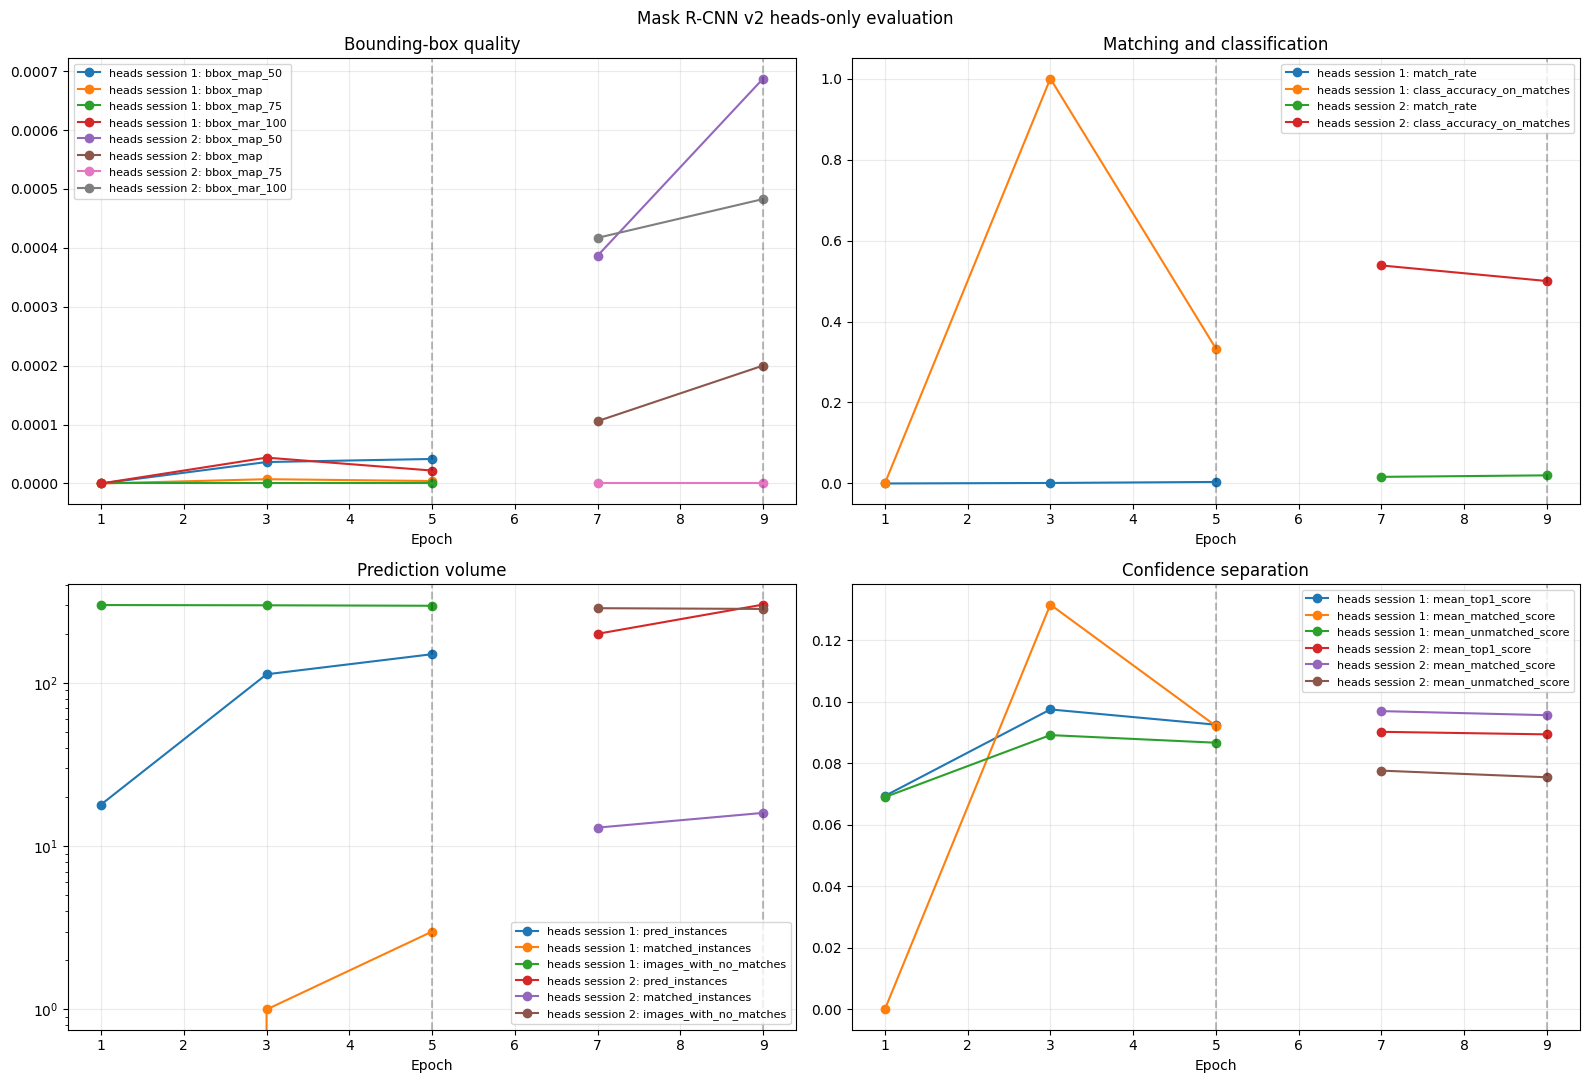

,session,epoch,eval/bbox_map_50,eval/bbox_map,eval/bbox_map_75,eval/bbox_mar_100,eval/match_rate,eval/class_accuracy_on_matches,eval/pred_instances,eval/matched_instances,eval/mean_matched_score,eval/mean_unmatched_score,lr
0,heads session 2,9,0.000687,0.000200,0.0,0.000483,0.020101,0.500000,302.0,16.0,0.095600,0.075435,0.000794
1,heads session 1,5,0.000042,0.000004,0.0,0.000022,0.003769,0.333333,150.0,3.0,0.092109,0.086660,0.000346


In [52]:
from pathlib import Path


def plot_mask_rcnn_eval_history(eval_paths, title):
    """Plot consistent evaluation diagnostics for one or more training sessions.

    Args:
        eval_paths (dict[str, str | Path]): Session names mapped to evaluation
            CSV paths.
        title (str): Figure title identifying the training stage.

    Returns:
        tuple[pandas.DataFrame, pandas.DataFrame]: Combined epoch history and
        one best-mAP row per session.
    """
    frames = []
    for session_name, csv_path in eval_paths.items():
        frame = pd.read_csv(csv_path)
        frame.columns = frame.columns.str.strip()
        frame["session"] = session_name
        frames.append(frame)

    history = pd.concat(frames, ignore_index=True)

    metric_groups = {
        "Bounding-box quality": [
            "eval/bbox_map_50",
            "eval/bbox_map",
            "eval/bbox_map_75",
            "eval/bbox_mar_100",
        ],
        "Matching and classification": [
            "eval/match_rate",
            "eval/class_accuracy_on_matches",
        ],
        "Prediction volume": [
            "eval/pred_instances",
            "eval/matched_instances",
            "eval/images_with_no_matches",
        ],
        "Confidence separation": [
            "eval/mean_top1_score",
            "eval/mean_matched_score",
            "eval/mean_unmatched_score",
        ],
    }

    figure, axes = plt.subplots(2, 2, figsize=(16, 11))

    for axis, (subtitle, columns) in zip(axes.ravel(), metric_groups.items()):
        for session_name, session_df in history.groupby("session", sort=False):
            session_df = session_df.sort_values("epoch")

            for column in columns:
                if column in session_df:
                    axis.plot(
                        session_df["epoch"],
                        session_df[column],
                        marker="o",
                        label=f"{session_name}: {column.removeprefix('eval/')}",
                    )

            if "eval/bbox_map_50" in session_df:
                best_index = session_df["eval/bbox_map_50"].idxmax()
                best_epoch = session_df.loc[best_index, "epoch"]
                axis.axvline(
                    best_epoch,
                    color="black",
                    linestyle="--",
                    alpha=0.25,
                )

        axis.set_title(subtitle)
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.25)
        axis.legend(fontsize=8)

        if subtitle == "Prediction volume":
            axis.set_yscale("log")

    figure.suptitle(title)
    figure.tight_layout()
    plt.show()

    best_indices = history.groupby("session")["eval/bbox_map_50"].idxmax()
    candidate_columns = [
        "session",
        "epoch",
        "eval/bbox_map_50",
        "eval/bbox_map",
        "eval/bbox_map_75",
        "eval/bbox_mar_100",
        "eval/match_rate",
        "eval/class_accuracy_on_matches",
        "eval/pred_instances",
        "eval/matched_instances",
        "eval/mean_matched_score",
        "eval/mean_unmatched_score",
        "lr",
    ]
    summary_columns = [column for column in candidate_columns if column in history]

    best_summary = (
        history.loc[best_indices, summary_columns]
        .sort_values("eval/bbox_map_50", ascending=False)
        .reset_index(drop=True)
    )

    return history, best_summary


head_eval_paths = {
    "heads session 1": Path(DATAFRAME_PATH) / "v2_heads_10_eval.csv",
    "heads session 2": Path(DATAFRAME_PATH) / "v2_heads_attempt_2_10_eval.csv",
}

df_heads, heads_best_summary = plot_mask_rcnn_eval_history(
    head_eval_paths,
    "Mask R-CNN v2 heads-only evaluation",
)

heads_best_summary

##### Heads-Only Observations

- Bounding-box mAP and recall remain low across both sessions. The second session does not produce the kind of sustained improvement expected from a converging detector.
- The model produces many candidate detections relative to the number of matched ground-truth objects. This indicates that proposal generation is active, but ranking and localization remain weak.
- Class accuracy on geometrically matched boxes is also limited, so the error is not purely missing proposals: classification remains a substantial bottleneck.
- Matched and unmatched confidence curves are insufficiently separated. Incorrect detections therefore remain competitive with correct detections in the ranking used to calculate average precision.
- This result is consistent with the v2 initialization used here. The RPN and ROI heads are trainable, but the FPN remains frozen even though `weights=None` does not provide detection-specific FPN weights. Full-model training is required before the v2 architecture can be judged fairly.

### Mask R-CNN v2 Full-Model Attempt 1

Unfreeze the complete v2 model and train with lower learning rate for the ResNet body and higher rates for the FPN, RPN, and ROI heads. As written, this block starts from a newly constructed model unless a checkpoint load is added after model creation.

In [34]:
num_epochs = 40
run_prefix = f"v2_full_tuning_stage_1_{num_epochs}"

In [ ]:
model_so = get_model_small_objects_v2(num_classes=num_classes_map17, train_mode="all")

In [36]:
optimizer_so = torch.optim.SGD([
    {"params": model_so.backbone.body.parameters(), "lr": 1e-4},  # ResNet50
    {"params": model_so.backbone.fpn.parameters(),  "lr": 1e-3},  # FPN — needs to learn!
    {"params": model_so.rpn.parameters(),           "lr": 1e-3},
    {"params": model_so.roi_heads.parameters(),     "lr": 1e-3},
], momentum=0.9, weight_decay=0.0005)
scheduler_so = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_so, T_max=num_epochs, eta_min=1e-6,
)
scaler_so = torch.amp.GradScaler("cuda")
writer_so = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}"))

In [37]:
history_so = train_model(
    model=model_so,
    train_loader=train_loader_map17,
    val_loader=val_loader_map17,
    optimizer=optimizer_so,
    scheduler=scheduler_so,
    scaler=scaler_so,
    writer=writer_so,
    num_epoch=num_epochs,
    run_prefix=run_prefix,
    device=device,
    eval_every=2,
    early_stopping_patience=8,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_map17,
    fast=True,
)

Train model. Epoch 30:  72%|███████▎  | 29/40 [4:23:47<1:40:03, 545.77s/it]

Early stopping: no improvement for 8 epochs (best was epoch 21)


In [38]:
if not is_google_colab():
    !rclone copy ./taco_trash gdrive:taco_trash --progress
    !rclone copy checkpoints gdrive:taco_trash/checkpoints --progress

Transferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 5
Elapsed time:         0.4sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 5
Elapsed time:         0.9sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 5
Elapsed time:         1.5sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 5
Elapsed time:         1.9sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 5
Elapsed time:         2.4sTransferred:   	          0 B / 0 B, -, 0 B/s, ETA -
Checks:                 0 / 0, -, Listed 108
Elapsed time:         3.0sTransferred:   	          0 B / 8.807 KiB, 0%, 0 B/s, ETA -
Checks:                 2 / 2, 100%, Listed 110
Transferred:            0 / 2, 0%
Elapsed time:         3.4s
Transferring:
 *            v2_full_tuning_stage_1_40_eval.csv:  0% / 5.166 KiB, 0 B/s, -
 *     

#### Visualize Full-Model Attempt 1

Apply the same diagnostic layout to the first full-model attempt. Keeping the axes and summary fields identical makes it possible to distinguish a genuine mAP improvement from a change caused only by prediction count, match rate, or confidence calibration.

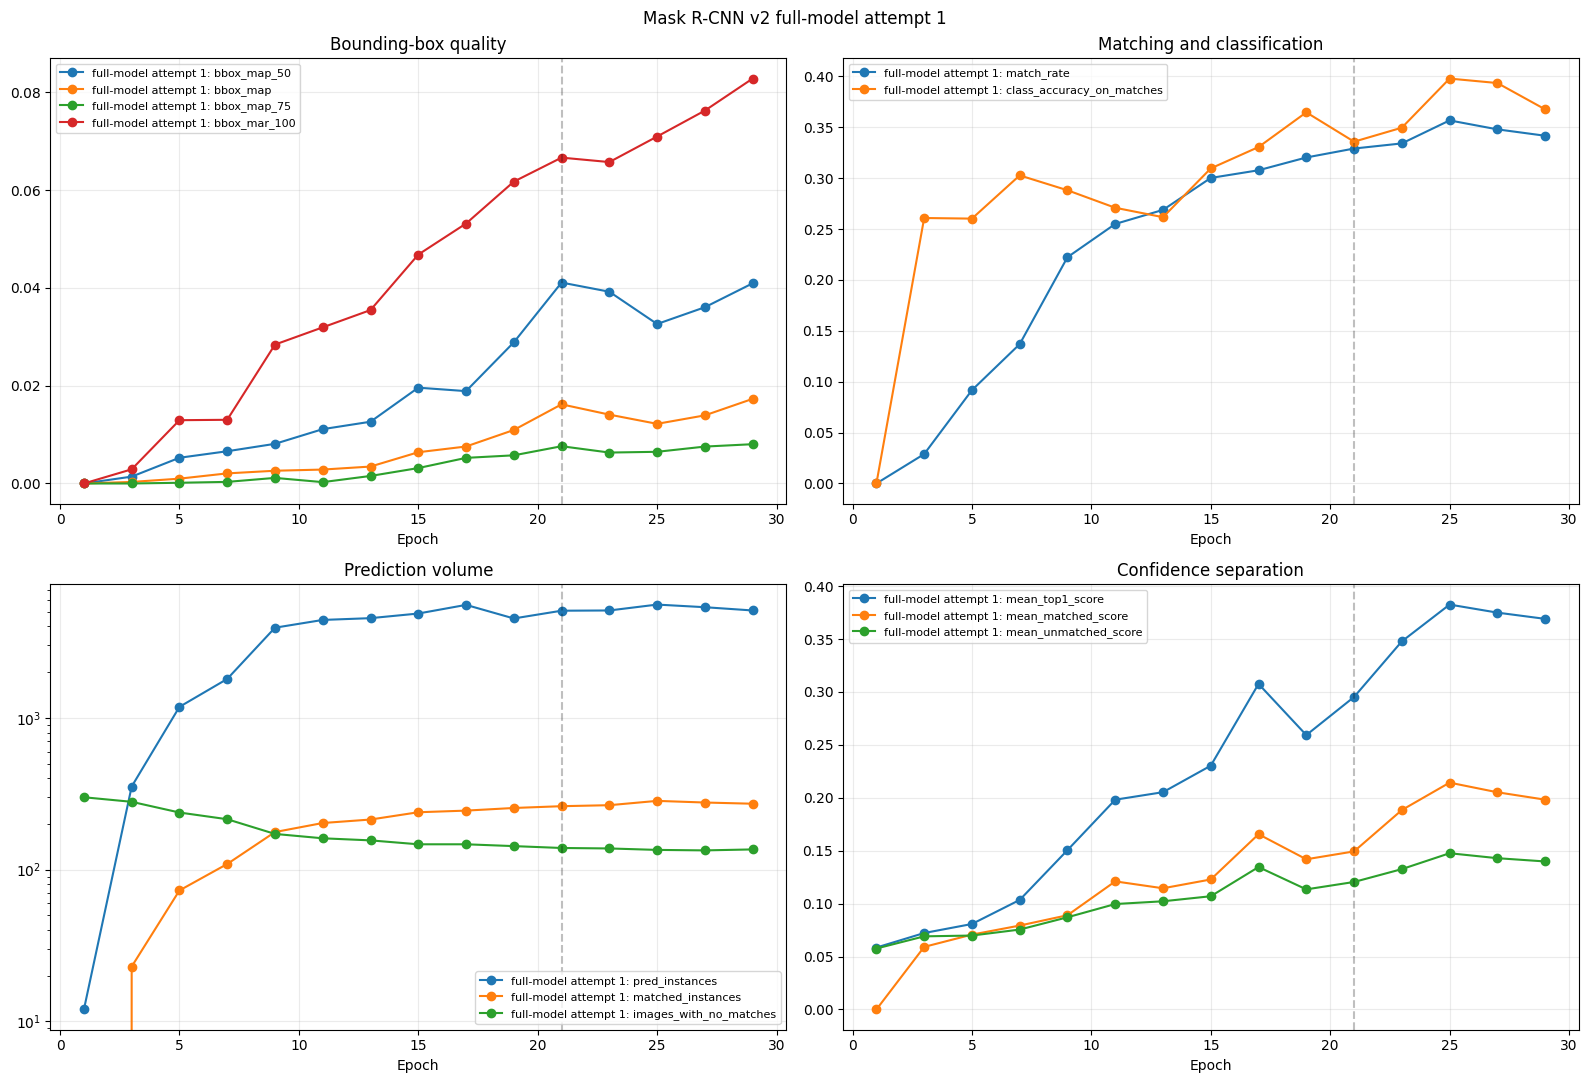

,session,epoch,eval/bbox_map_50,eval/bbox_map,eval/bbox_map_75,eval/bbox_mar_100,eval/match_rate,eval/class_accuracy_on_matches,eval/pred_instances,eval/matched_instances,eval/mean_matched_score,eval/mean_unmatched_score,lr
0,full-model attempt 1,21,0.041105,0.016192,0.007621,0.066666,0.329146,0.335878,5082.0,262.0,0.149351,0.120469,0.000047


In [51]:
df_cycle_1, cycle_1_best_summary = plot_mask_rcnn_eval_history(
    {
        "full-model attempt 1": Path(DATAFRAME_PATH)
        / "v2_full_tuning_stage_1_40_eval.csv",
    },
    "Mask R-CNN v2 full-model attempt 1",
)

cycle_1_best_summary

##### Full-Model Attempt 1 Observations

- Unfreezing the complete model improves detection over the heads-only baseline, confirming that the frozen feature pyramid was limiting learning.
- The best bbox `mAP@0.5` remains only about `0.041`, however, and the gap between mAP@0.5 and stricter localization metrics remains large.
- Match rate and confidence calibration fluctuate rather than improving monotonically. The model finds more objects, but many detections are still unmatched or ranked too highly.
- Early stopping is appropriate because the validation curves plateau while training continues. More epochs with the same initialization and learning rates are unlikely to close the gap to Mask R-CNN v1.

### Mask R-CNN v2 Full-Model Attempt 2

Repeat full-model optimization with the same differential learning-rate structure over a shorter schedule. This block also constructs a new model, so its metrics represent a separate attempt unless prior weights are loaded explicitly.

In [ ]:
num_epochs = 25
run_prefix = f"v2_full_tuning_stage_2_{num_epochs}"

In [ ]:
model_so = get_model_small_objects_v2(num_classes=num_classes_map17, train_mode="all")

In [ ]:
optimizer_so = torch.optim.SGD([
    {"params": model_so.backbone.body.parameters(), "lr": 1e-4},  # ResNet50
    {"params": model_so.backbone.fpn.parameters(),  "lr": 1e-3},  # FPN — needs to learn!
    {"params": model_so.rpn.parameters(),           "lr": 1e-3},
    {"params": model_so.roi_heads.parameters(),     "lr": 1e-3},
], momentum=0.9, weight_decay=0.0005)
scheduler_so = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_so, T_max=num_epochs, eta_min=1e-6,
)
scaler_so = torch.amp.GradScaler("cuda")
writer_so = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}"))

In [ ]:
history_so = train_model(
    model=model_so,
    train_loader=train_loader_map17,
    val_loader=val_loader_map17,
    optimizer=optimizer_so,
    scheduler=scheduler_so,
    scaler=scaler_so,
    writer=writer_so,
    num_epoch=num_epochs,
    run_prefix=run_prefix,
    device=device,
    eval_every=2,
    early_stopping_patience=8,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_map17,
    fast=True,
)

Train model. Epoch 30:  72%|███████▎  | 29/40 [4:23:47<1:40:03, 545.77s/it]

Early stopping: no improvement for 8 epochs (best was epoch 21)


#### Visualize Full-Model Attempt 2

Load the evaluation history for the second v2 full-model attempt. Plotting the same metric groups used above makes changes in localization, classification, and prediction volume directly comparable with the heads-only baseline.

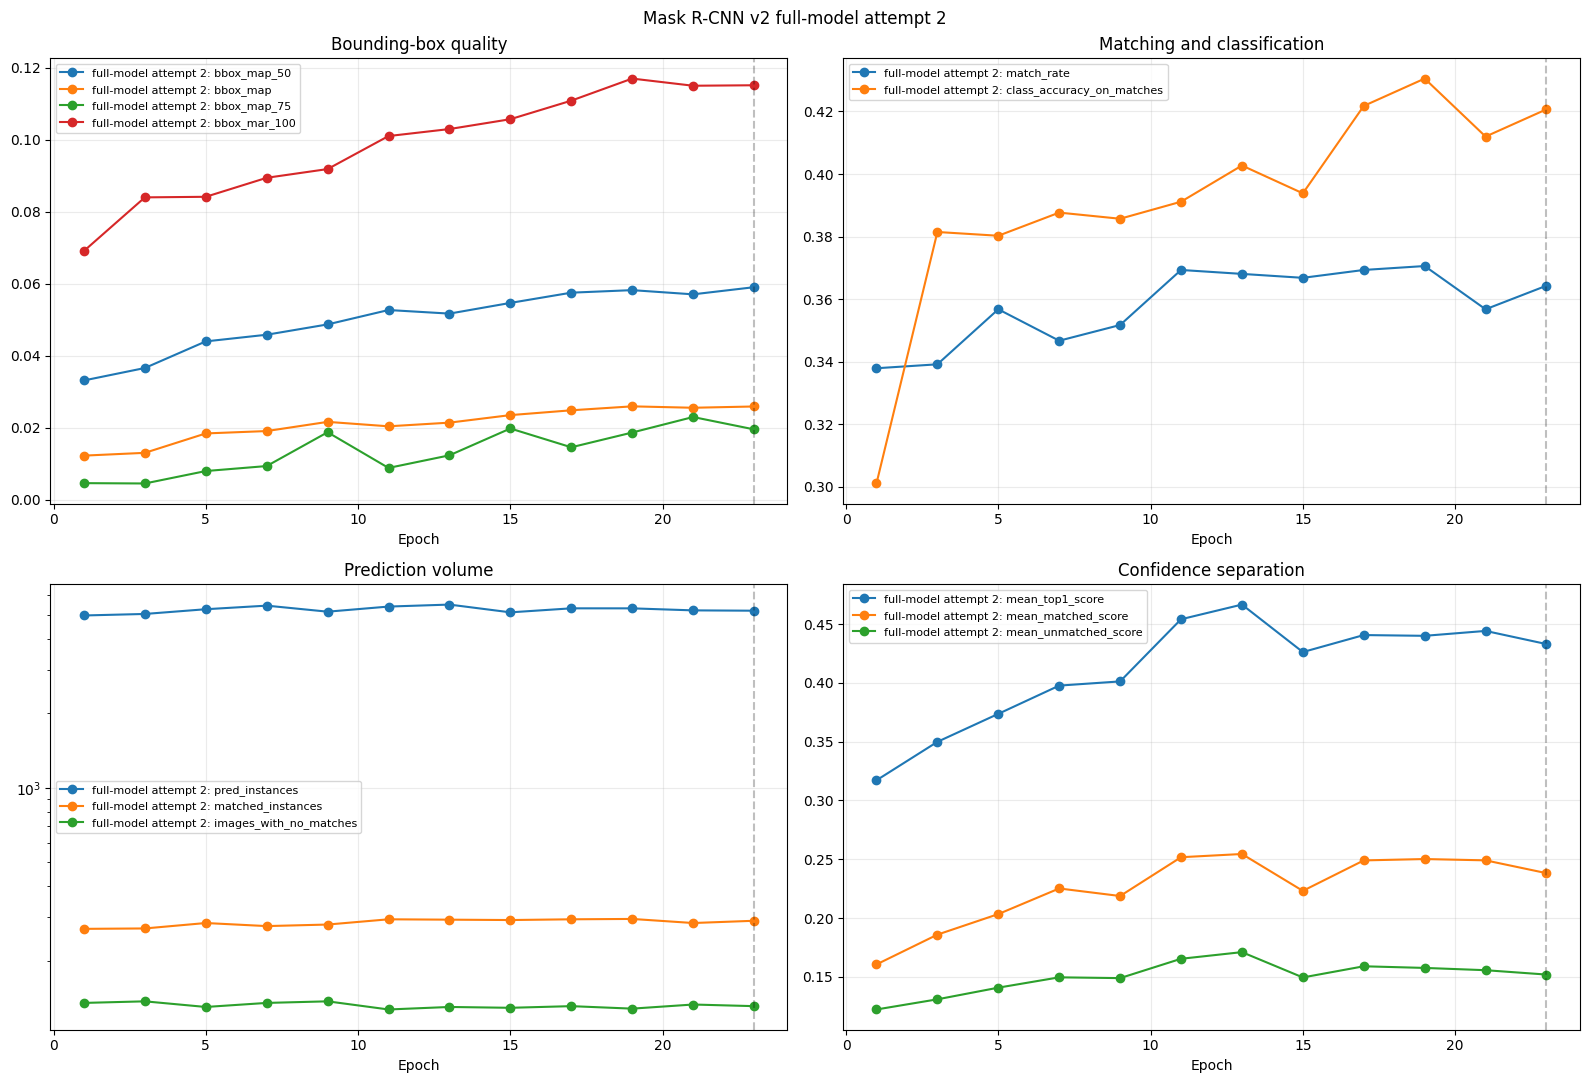

,session,epoch,eval/bbox_map_50,eval/bbox_map,eval/bbox_map_75,eval/bbox_mar_100,eval/match_rate,eval/class_accuracy_on_matches,eval/pred_instances,eval/matched_instances,eval/mean_matched_score,eval/mean_unmatched_score,lr
0,full-model attempt 2,23,0.058993,0.025869,0.019512,0.115071,0.364322,0.42069,5199.0,290.0,0.238164,0.15195,0.000002


In [50]:
df_cycle_2, cycle_2_best_summary = plot_mask_rcnn_eval_history(
    {
        "full-model attempt 2": Path(DATAFRAME_PATH)
        / "v2_full_tuning_stage_2_25_eval.csv",
    },
    "Mask R-CNN v2 full-model attempt 2",
)

cycle_2_best_summary

##### Full-Model Attempt 2 Observations

- The second attempt does not establish a stable improvement over the first full-model run. mAP, recall, and class accuracy continue to fluctuate between evaluations.
- Prediction volume remains much larger than the number of matched instances. Increasing proposal count therefore does not translate directly into better average precision.
- The matched-versus-unmatched score gap remains narrow, showing that confidence ranking is still one of the main limitations.
- Because this block constructs a fresh model, the plot should be interpreted as another independent optimization attempt, not as additional epochs applied to attempt 1.

### Mask R-CNN v2 Full-Model Attempt 3

Test a more aggressive learning-rate configuration for all detection-specific components. The purpose is to determine whether the weak earlier results are caused by under-training, while monitoring for unstable losses and degraded validation mAP.

In [ ]:
num_epochs = 30
run_prefix = f"v2_full_tuning_stage_3_{num_epochs}"

In [ ]:
model_so = get_model_small_objects_v2(num_classes=num_classes_map17, train_mode="all")

In [ ]:
optimizer_so = torch.optim.SGD([
    {"params": model_so.backbone.body.parameters(), "lr": 5e-4},  # ResNet50
    {"params": model_so.backbone.fpn.parameters(),  "lr": 5e-3},  # FPN — needs to learn!
    {"params": model_so.rpn.parameters(),           "lr": 5e-3},
    {"params": model_so.roi_heads.parameters(),     "lr": 5e-3},
], momentum=0.9, weight_decay=0.0005)
scheduler_so = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_so, T_max=num_epochs, eta_min=1e-6,
)
scaler_so = torch.amp.GradScaler("cuda")
writer_so = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}"))

In [ ]:
history_so = train_model(
    model=model_so,
    train_loader=train_loader_map17,
    val_loader=val_loader_map17,
    optimizer=optimizer_so,
    scheduler=scheduler_so,
    scaler=scaler_so,
    writer=writer_so,
    num_epoch=num_epochs,
    run_prefix=run_prefix,
    device=device,
    eval_every=2,
    early_stopping_patience=8,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_map17,
    fast=True,
)

Train model. Epoch 30:  72%|███████▎  | 29/40 [4:23:47<1:40:03, 545.77s/it]

Early stopping: no improvement for 8 epochs (best was epoch 21)


#### Visualize Full-Model Attempt 3

Inspect whether the higher learning rates improve mAP and recall or instead increase unstable and unmatched predictions.

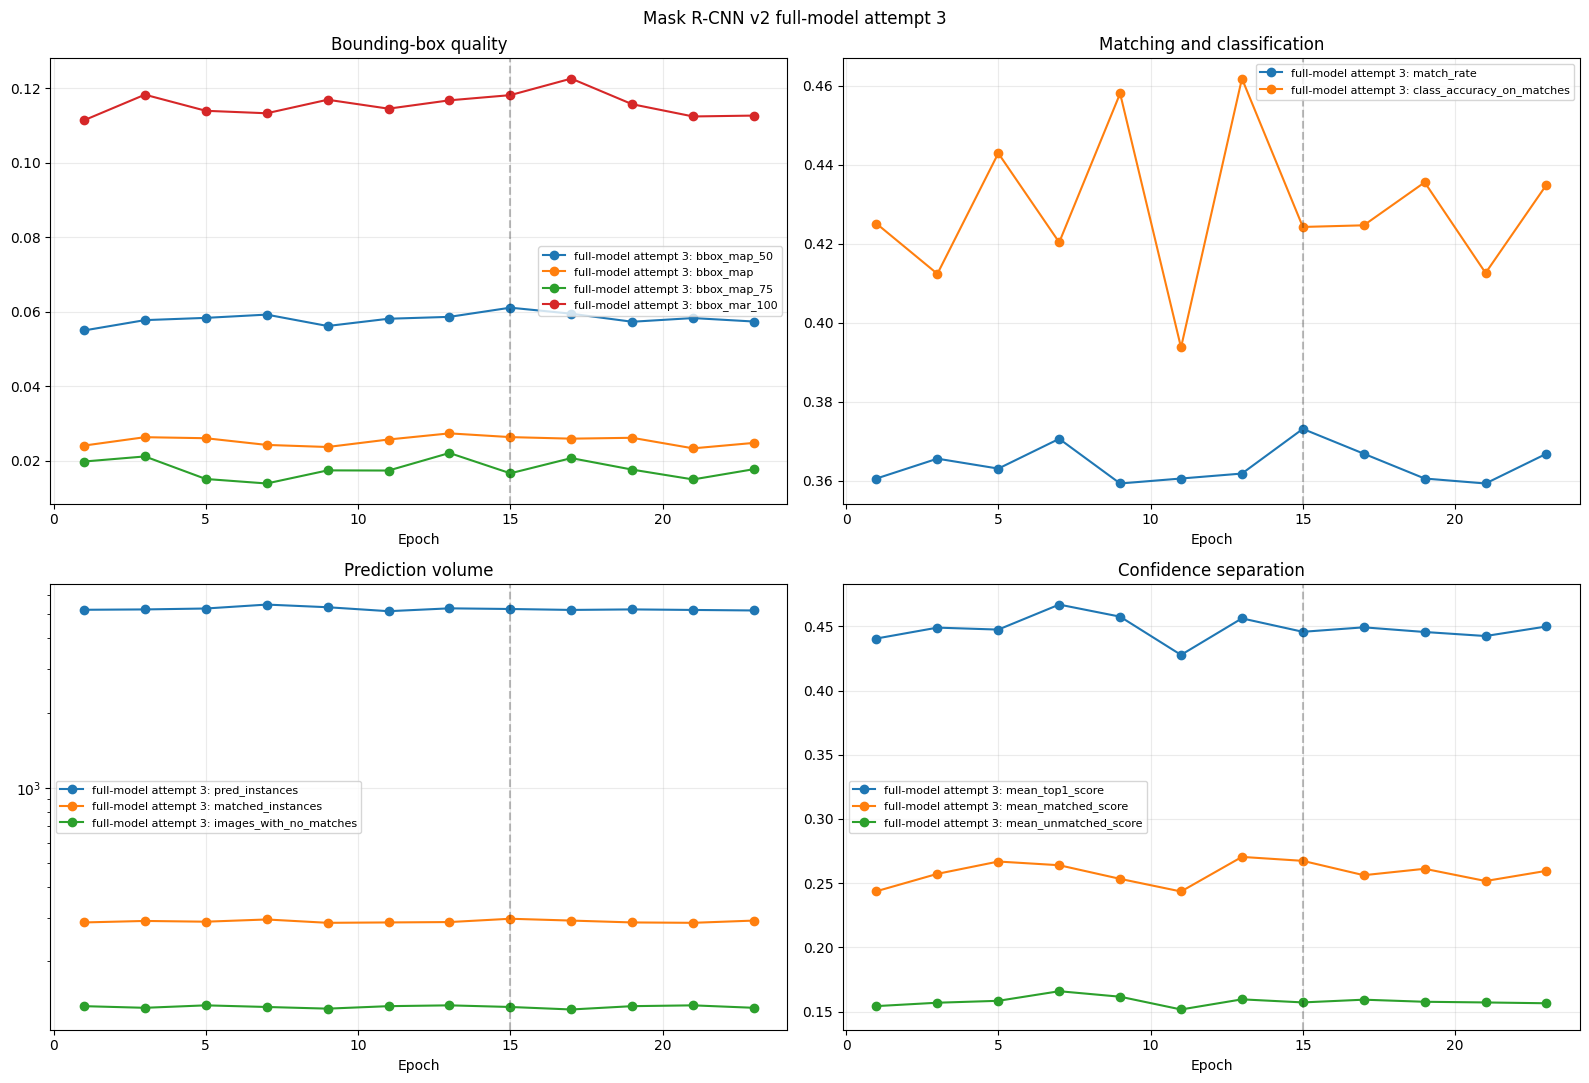

,session,epoch,eval/bbox_map_50,eval/bbox_map,eval/bbox_map_75,eval/bbox_mar_100,eval/match_rate,eval/class_accuracy_on_matches,eval/pred_instances,eval/matched_instances,eval/mean_matched_score,eval/mean_unmatched_score,lr
0,full-model attempt 3,15,0.06114,0.026397,0.016681,0.118193,0.373116,0.424242,5257.0,297.0,0.267423,0.157244,0.000001


In [49]:
df_cycle_3, cycle_3_best_summary = plot_mask_rcnn_eval_history(
    {
        "full-model attempt 3": Path(DATAFRAME_PATH)
        / "v2_full_tuning_stage_3_30_eval.csv",
    },
    "Mask R-CNN v2 full-model attempt 3",
)

cycle_3_best_summary

##### Full-Model Attempt 3 Observations

- The higher learning-rate configuration raises the best bbox `mAP@0.5` to approximately `0.062`, which is an improvement over the earlier v2 attempts.
- The gain is still modest relative to the increase in optimization aggressiveness, and the curves remain noisy rather than showing smooth convergence.
- Recall and match rate improve only partially, while class accuracy and score separation continue to constrain mAP.
- This attempt shows that the earlier schedules were probably conservative, but learning rate alone is not the main reason v2 underperforms.

### Mask R-CNN v2 Full-Model Attempt 4

Run another full-model experiment with the higher differential learning rates and retain the best checkpoint according to bounding-box `mAP@0.5`.

In [ ]:
num_epochs = 25
run_prefix = f"v2_full_tuning_stage_4_{num_epochs}"

In [ ]:
model_so = get_model_small_objects_v2(num_classes=num_classes_map17, train_mode="all")

In [ ]:
optimizer_so = torch.optim.SGD([
    {"params": model_so.backbone.body.parameters(), "lr": 5e-4},  # ResNet50
    {"params": model_so.backbone.fpn.parameters(),  "lr": 5e-3},  # FPN — needs to learn!
    {"params": model_so.rpn.parameters(),           "lr": 5e-3},
    {"params": model_so.roi_heads.parameters(),     "lr": 5e-3},
], momentum=0.9, weight_decay=0.0005)
scheduler_so = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_so, T_max=num_epochs, eta_min=1e-6,
)
scaler_so = torch.amp.GradScaler("cuda")
writer_so = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}"))

In [ ]:
history_so = train_model(
    model=model_so,
    train_loader=train_loader_map17,
    val_loader=val_loader_map17,
    optimizer=optimizer_so,
    scheduler=scheduler_so,
    scaler=scaler_so,
    writer=writer_so,
    num_epoch=num_epochs,
    run_prefix=run_prefix,
    device=device,
    eval_every=2,
    early_stopping_patience=8,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_map17,
    fast=True,
)

Train model. Epoch 30:  72%|███████▎  | 29/40 [4:23:47<1:40:03, 545.77s/it]

Early stopping: no improvement for 8 epochs (best was epoch 21)


#### Visualize Full-Model Attempt 4

Review the fourth attempt's best epoch and determine whether validation quality exceeds the earlier v2 runs.

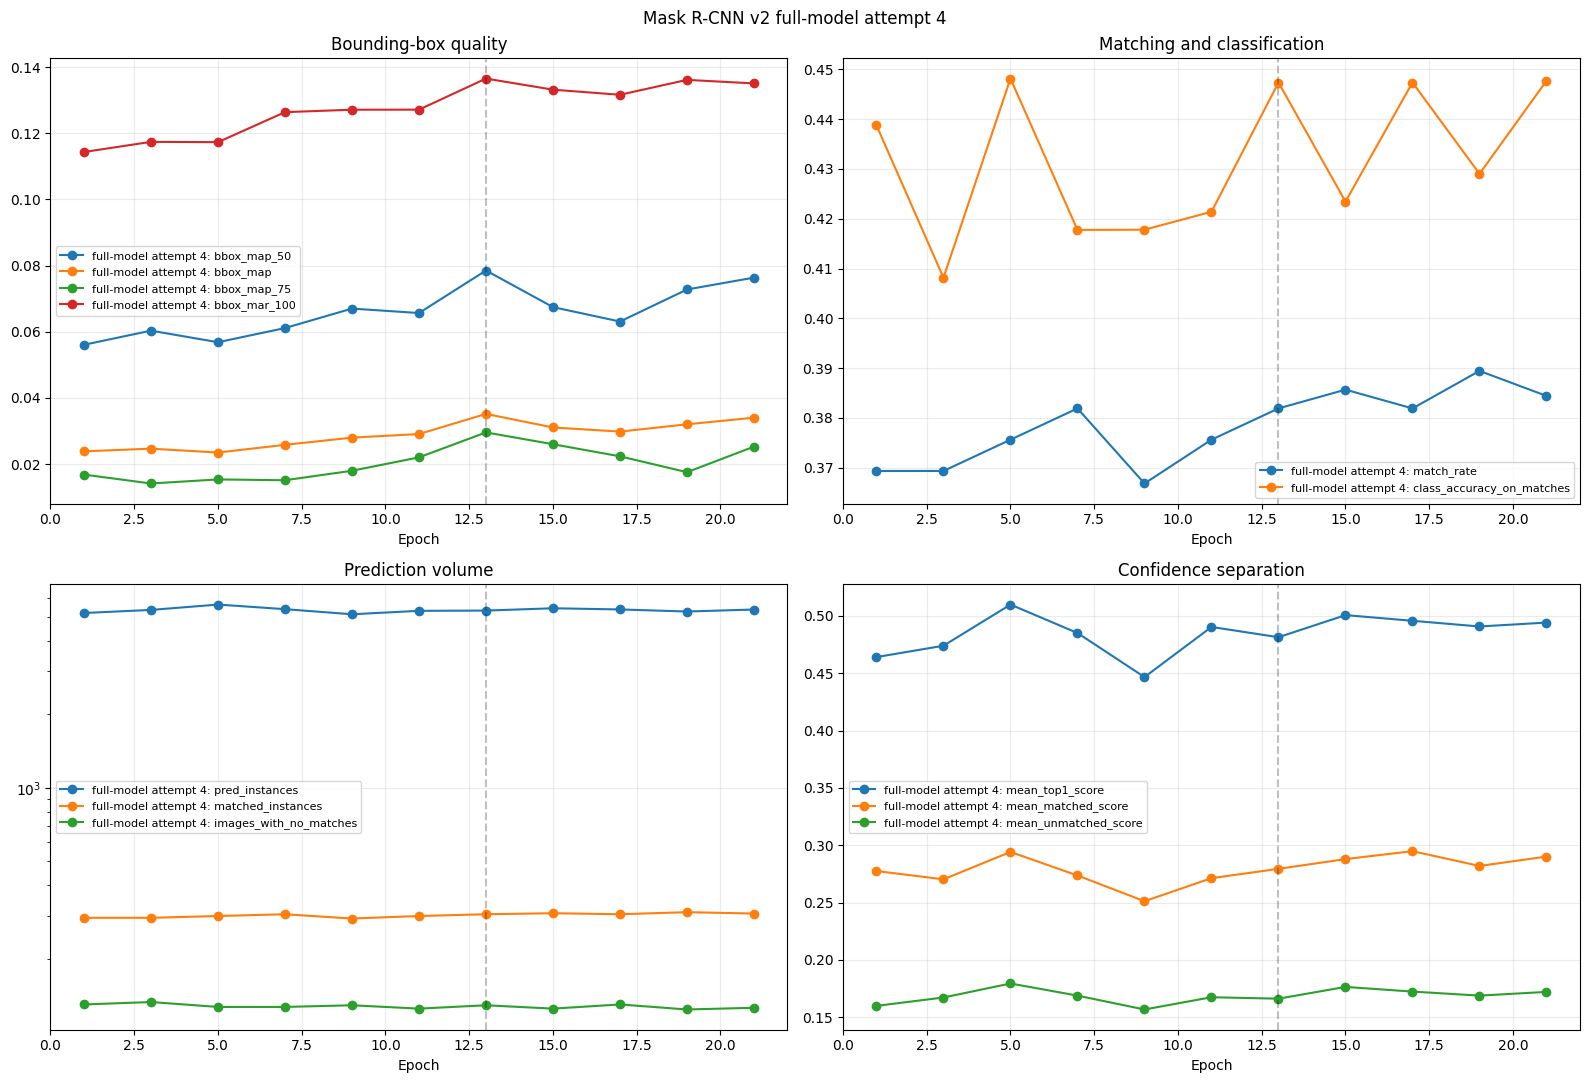

,session,epoch,eval/bbox_map_50,eval/bbox_map,eval/bbox_map_75,eval/bbox_mar_100,eval/match_rate,eval/class_accuracy_on_matches,eval/pred_instances,eval/matched_instances,eval/mean_matched_score,eval/mean_unmatched_score,lr
0,full-model attempt 4,13,0.078514,0.035185,0.029595,0.136503,0.38191,0.447368,5308.0,304.0,0.279424,0.166239,0.00001


In [47]:
df_cycle_4, cycle_4_best_summary = plot_mask_rcnn_eval_history(
    {
        "full-model attempt 4": Path(DATAFRAME_PATH)
        / "v2_full_tuning_stage_4_25_eval.csv",
    },
    "Mask R-CNN v2 full-model attempt 4",
)

cycle_4_best_summary

##### Full-Model Attempt 4 Observations

- Attempt 4 produces the strongest Mask R-CNN v2 checkpoint, reaching approximately `0.079` bbox mAP@0.5 and `0.035` COCO-style bbox mAP.
- Even at this peak, stricter localization quality remains low and the model still generates substantially more predictions than matched objects.
- The best epoch occurs before the end of the configured schedule, followed by a plateau or regression. The best checkpoint is therefore more meaningful than the final checkpoint.
- This is the correct v2 checkpoint to retain for comparison, but its margin over attempt 3 is small and it remains far below Mask R-CNN v1.

### Mask R-CNN v2 Full-Model Attempt 5

Perform the final short v2 training attempt and evaluate whether additional optimization improves on the best earlier v2 checkpoint. The resulting plateau provides evidence for stopping v2 development rather than extending the same schedule indefinitely.

In [ ]:
num_epochs = 15
run_prefix = f"v2_full_tuning_stage_5_{num_epochs}"

In [ ]:
model_so = get_model_small_objects_v2(num_classes=num_classes_map17, train_mode="all")

In [ ]:
optimizer_so = torch.optim.SGD([
    {"params": model_so.backbone.body.parameters(), "lr": 5e-4},  # ResNet50
    {"params": model_so.backbone.fpn.parameters(),  "lr": 5e-3},  # FPN — needs to learn!
    {"params": model_so.rpn.parameters(),           "lr": 5e-3},
    {"params": model_so.roi_heads.parameters(),     "lr": 5e-3},
], momentum=0.9, weight_decay=0.0005)
scheduler_so = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_so, T_max=num_epochs, eta_min=1e-6,
)
scaler_so = torch.amp.GradScaler("cuda")
writer_so = SummaryWriter(log_dir=os.path.join(DEFAULT_RUNS_PATH, f"runs/{run_prefix}"))

In [ ]:
history_so = train_model(
    model=model_so,
    train_loader=train_loader_map17,
    val_loader=val_loader_map17,
    optimizer=optimizer_so,
    scheduler=scheduler_so,
    scaler=scaler_so,
    writer=writer_so,
    num_epoch=num_epochs,
    run_prefix=run_prefix,
    device=device,
    eval_every=2,
    early_stopping_patience=8,
    metrics_csv_paths={
        "train": os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_train.csv"),
        "eval":  os.path.join(DEFAULT_RUNS_PATH, f"{run_prefix}_eval.csv"),
    },
    checkpoint_score_fn=score_by_eval_bbox_map_50,
    scheduler_step_fn=step_cosine,
    id_to_name=id_to_name_map17,
    fast=True,
)

Train model. Epoch 30:  72%|███████▎  | 29/40 [4:23:47<1:40:03, 545.77s/it]

Early stopping: no improvement for 8 epochs (best was epoch 21)


#### Visualize Full-Model Attempt 5

Inspect the final v2 history for a genuine upward trend. A flat or declining mAP curve after learning-rate reduction indicates that additional epochs with the same model and data configuration are unlikely to help.

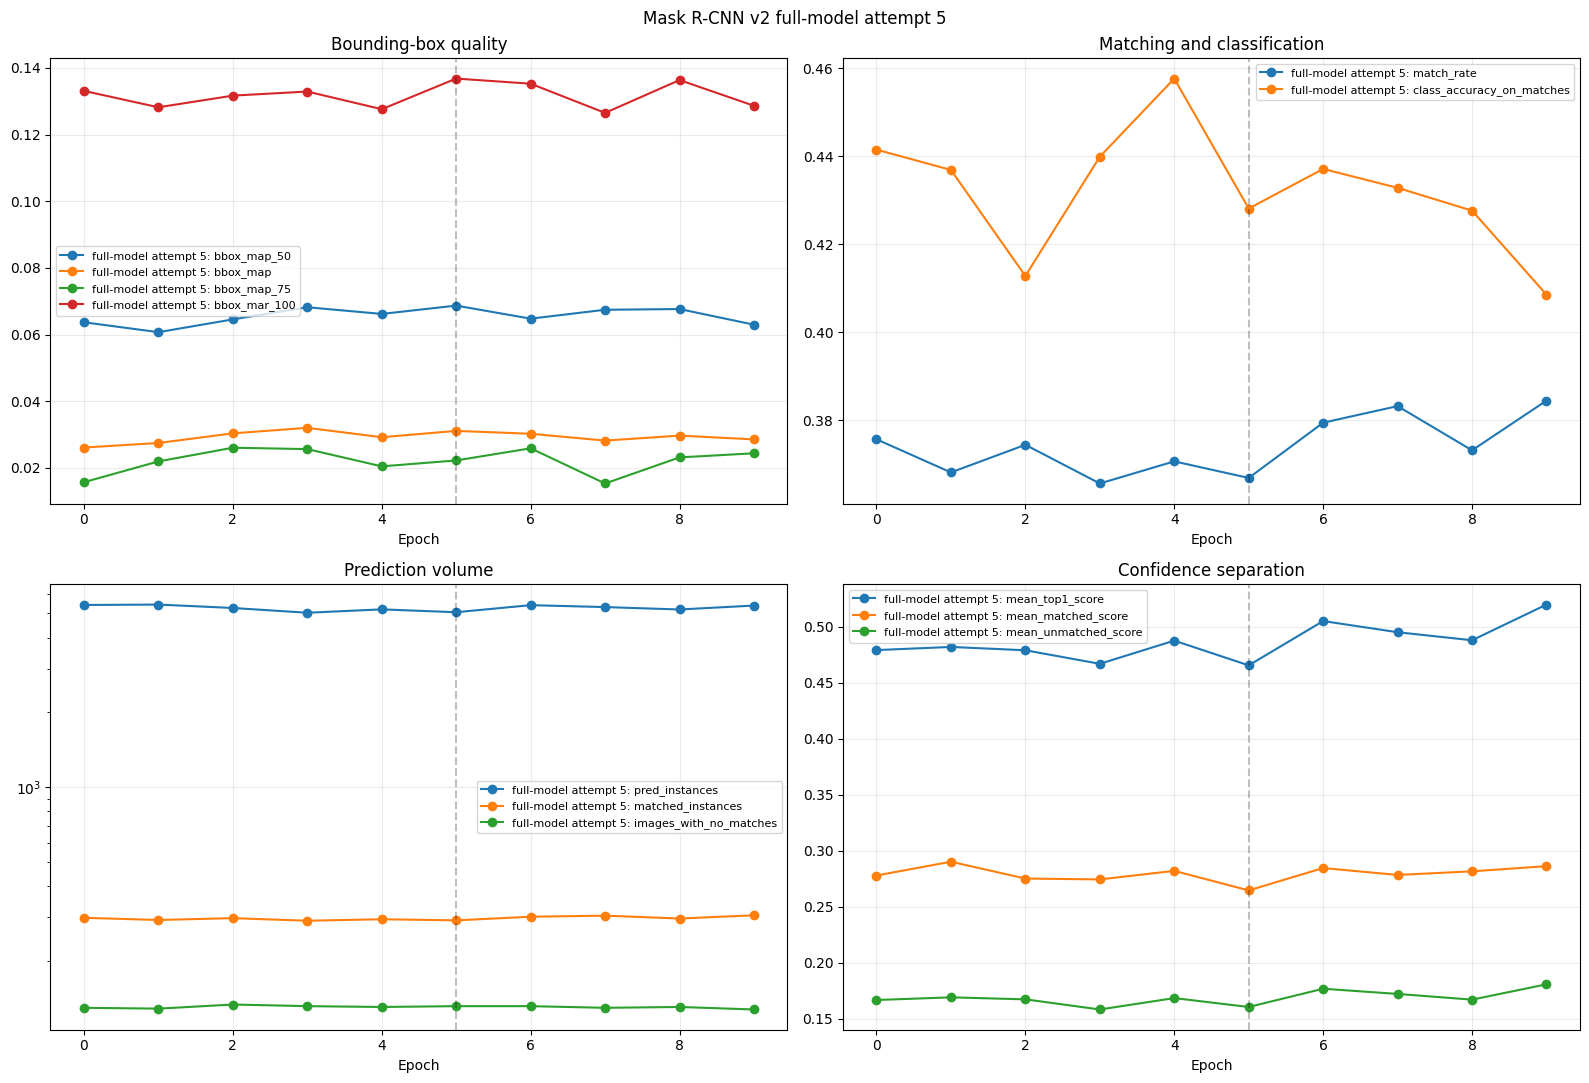

,session,epoch,eval/bbox_map_50,eval/bbox_map,eval/bbox_map_75,eval/bbox_mar_100,eval/match_rate,eval/class_accuracy_on_matches,eval/pred_instances,eval/matched_instances,eval/mean_matched_score,eval/mean_unmatched_score,lr
0,full-model attempt 5,5,0.068701,0.031116,0.022251,0.136798,0.366834,0.428082,5055.0,292.0,0.264707,0.160589,0.000005


In [48]:
df_cycle_5, cycle_5_best_summary = plot_mask_rcnn_eval_history(
    {
        "full-model attempt 5": Path(DATAFRAME_PATH)
        / "v2_full_tuning_stage_5_15_eval.csv",
    },
    "Mask R-CNN v2 full-model attempt 5",
)

cycle_5_best_summary

##### Full-Model Attempt 5 Observations

- The final attempt reaches a best bbox `mAP@0.5` of about `0.069` at epoch 5, below the approximately `0.079` achieved by attempt 4.
- COCO-style bbox mAP remains near `0.031`, mAP@0.75 remains very low, and match rate stays around `0.37`. This indicates persistent localization and recall problems.
- Roughly 5,000 predictions are produced for 796 ground-truth objects, while only about 300 are geometrically matched. False-positive ranking remains a major source of lost precision.
- Reducing the learning rate later in the run does not recover the earlier peak. The metric movement is consistent with validation noise around a plateau rather than continued learning.
- Attempt 5 therefore provides negative evidence for further v2 cycles with the same data, initialization, and model configuration.

## Overall Conclusion

Five full-model Mask R-CNN v2 attempts were evaluated after the unsuccessful heads-only stage. Full unfreezing improved the model, but repeated changes to learning rate and schedule did not produce a competitive detector. The strongest v2 result was obtained in attempt 4 at approximately:

| Model | bbox mAP@0.5 | bbox mAP@0.5:0.95 |
|:--|--:|--:|
| Mask R-CNN v1 | **0.187** | **0.126** |
| Mask R-CNN v2, best attempt | 0.079 | 0.035 |

The best v2 checkpoint is about 58% lower in mAP@0.5 and about 72% lower in COCO-style bbox mAP than Mask R-CNN v1. Its match rate, localization at higher IoU thresholds, confidence separation, and class accuracy also remain weak. Attempt 5 regresses rather than extending the attempt-4 peak, which indicates that the experiment has reached a practical plateau.

It therefore does not make sense to continue training this Mask R-CNN v2 configuration. Attempt 4 should be retained as the best v2 checkpoint for documentation, while Mask R-CNN v1 remains the preferred instance-segmentation model. Further compute should be spent on architectures that have already demonstrated stronger detection quality, such as YOLO, or on changes to the data and taxonomy rather than a sixth v2 cycle.

This conclusion applies to the specific v2 initialization and training pipeline in this notebook. In particular, the model starts without detection-specific pretrained v2 weights, and several blocks recreate the model instead of explicitly continuing the previous best checkpoint. Those choices help explain the poor result, but repeating the existing workflow unchanged is not justified by the observed metrics.